In [9]:

import matplotlib.pyplot as plt
import matplotlib.tri as mtri

import math
from typing import Dict, List, Tuple, Literal,Optional
import numpy as np
#NeighborMode = Literal["Edges", "Extented_edges"]

# mesh 생성 코드
def mesh(
    x_s: float, x_f: float,
    y_s: float, y_f: float,
    x_c: float, y_c: float,
    r: float, mod: str

) -> Tuple[np.ndarray, Dict[Tuple[int, int], int]]:
    """
    Equilateral triangular mesh (side length r) inside rectangle [x_s,x_f] x [y_s,y_f],
    anchored at (x_c, y_c).

    Returns:
      vertices: (N,2) float array
      idx_map: dict mapping (i,j) -> vertex_index (lattice coords)
    """
    if r <= 0:
        raise ValueError("r must be positive.")
    if x_s > x_f:
        x_s, x_f = x_f, x_s
    if y_s > y_f:
        y_s, y_f = y_f, y_s
    mod=mod.strip()
    if mod == "Square":
        i_min = math.ceil((x_s - x_c) / r)
        i_max = math.floor((x_f - x_c) / r)
        j_min = math.ceil((y_s - y_c) / r)
        j_max = math.floor((y_f - y_c) / r)

        vertices: List[Tuple[float, float]] = []
        idx_map: Dict[Tuple[int, int], int] = {}

        for j in range(j_min, j_max + 1):
            y = y_c + j * r
            for i in range(i_min, i_max + 1):
                x = x_c + i * r
                # boundary included
                if (x_s <= x <= x_f) and (y_s <= y <= y_f):
                    idx_map[(i, j)] = len(vertices)
                    vertices.append((x, y))

        return np.array(vertices, dtype=float), idx_map
    if mod=='Hexa':
        dy = r * math.sqrt(3) / 2.0  # row spacing

        j_min = math.ceil((y_s - y_c ) / dy)
        j_max = math.floor((y_f - y_c ) / dy)

        vertices: List[Tuple[float, float]] = []
        idx_map: Dict[Tuple[int, int], int] = {}

        for j in range(j_min, j_max + 1):
            y = y_c + j * dy

            # x = x_c + i*r + j*(r/2)
            i_min = math.ceil((x_s - x_c - (j * r / 2.0)) / r)
            i_max = math.floor((x_f - x_c - (j * r / 2.0) ) / r)

            for i in range(i_min, i_max + 1):
                x = x_c + i * r + j * (r / 2.0)
                if (x_s) <= x <= (x_f) and (y_s) <= y <= (y_f):
                    idx_map[(i, j)] = len(vertices)
                    vertices.append((x, y))
        return np.array(vertices, dtype=float),  idx_map


def vertex_index_from_xy(
    x: float, y: float,
    idx_map: Dict[Tuple[int, int], int],
    mod: Literal["Square", "Hexa"],
    x_c: float, y_c: float,
    r: float,
) -> int:
    """
    Return vertex index for the nearest lattice vertex to (x,y).
    Uses idx_map from mesh().

    Square:
      i = round((x-x_c)/r), j = round((y-y_c)/r)

    Hexa:
      dy = r*sqrt(3)/2
      j = round((y-y_c)/dy)
      i = round((x-x_c - j*(r/2))/r)
    """
    mod = mod.strip()
    if r <= 0:
        raise ValueError("r must be positive.")

    if mod == "Square":
        i = int(round((x - x_c) / r))
        j = int(round((y - y_c) / r))
    elif mod == "Hexa":
        dy = r * math.sqrt(3) / 2.0
        j = int(round((y - y_c) / dy))
        i = int(round((x - x_c - j * (r / 2.0)) / r))
    else:
        raise ValueError("mod must be 'Square' or 'Hexa'.")

    key = (i, j)
    if key not in idx_map:
        raise KeyError(f"(x,y)=({x},{y}) -> (i,j)=({i},{j}) not in idx_map (outside domain?)")
    return idx_map[key]

mesh_mode = Literal["Square", "Hexa"]
NeighborMode = Literal["Edges_only", "Extended_edges","Extra_extended_edges"]
#인접한 mesh 분석
def build_vertex_adjacency(
    idx_map: Dict[Tuple[int, int], int],
    num_vertices: int,
    mod: mesh_mode = "Hexa",
    mode: NeighborMode = "Extended_edges",
    *,
    missing: int = -1,   # 없는 이웃 채우는 값
) -> Tuple[np.ndarray, List[Tuple[int, int]]]:
    """
    Returns:
      adj: (N, K) int array, adj[v, k] = neighbor index or 'missing'
      offsets: length K, adjacency index k가 의미하는 (di, dj)
    """
    mod = mod.strip()
    mode = mode.strip()

    # ---- offsets depending on mesh type ----
    if mod == "Square":
        offsets = [(0, 1), (1, 0), (0, -1), (-1, 0)]
        if mode in ("Extended_edges", "Extra_extended_edges"):
            offsets = [
                (0, 1), (1, 1), (1, 0), (1, -1),
                (0, -1), (-1, -1), (-1, 0), (-1, 1),
            ]
        if mode == "Extra_extended_edges":
            offsets = [
                (0, 1), (1, 2), (1, 1), (2, 1),
                (1, 0), (2, -1), (1, -1), (1, -2),
                (0, -1), (-1, -2), (-1, -1), (-2, -1),
                (-1, 0), (-2, 1), (-1, 1), (-1, 2),
            ]

    elif mod == "Hexa":
        offsets = [(0,1),(1,0),(1,-1),(0,-1),(-1,0),(-1,1)]
        if mode in ("Extended_edges", "Extra_extended_edges"):
            offsets = [
                (-1,2),(0,1),(1,1),(1,0),(2,-1),(1,-1),
                (1,-2),(0,-1),(-1,-1),(-1,0),(-2,1),(-1,1)
            ]
        if mode == "Extra_extended_edges":
            offsets = [
                (-1,2),(-1,3),(0,1),(1,2),(1,1),(2,1),
                (1,0),(3,-1),(2,-1),(3,-2),(1,-1),(2,-3),
                (1,-2),(1,-3),(0,-1),(-1,-2),(-1,-1),(-2,-1),
                (-1,0),(-3,1),(-2,1),(-3,2),(-1,1),(-2,3)
            ]
    else:
        raise ValueError("mod must be 'Square' or 'Hexa'.")

    K = len(offsets)
    adj = np.full((num_vertices, K), missing, dtype=np.int32)

    # idx_map의 (i,j)마다 K개 슬롯을 채운다
    for (i, j), v in idx_map.items():
        for k, (di, dj) in enumerate(offsets):
            u = idx_map.get((i + di, j + dj))
            if u is not None:
                adj[v, k] = u

    return adj
def angle_from_y_clockwise_deg(dx: float, dy: float) -> float:
    """0°=+y, 90°=+x, 180°=-y, 270°=-x"""
    ang = math.degrees(math.atan2(dx, dy))
    return (ang + 360.0) % 360.0

def build_adjacency_angles(
    vertices: np.ndarray,     # (N,2)
    adj_fixed: np.ndarray,    # (N,K)  (-1 for missing)
    *,
    missing_angle: float = float("nan"),
) -> np.ndarray:
    """
    Returns:
      ang: (N,K) float array, ang[v,k] = angle_deg or NaN if missing neighbor
    """
    N, K = adj_fixed.shape
    ang = np.full((N, K), missing_angle, dtype=np.float64)

    for v in range(N):
        xv, yv = vertices[v]
        for k in range(K):
            u = int(adj_fixed[v, k])
            if u < 0:
                continue
            xu, yu = vertices[u]
            dx, dy = (xu - xv), (yu - yv)
            ang[v, k] = angle_from_y_clockwise_deg(dx, dy)

    return ang

def fixed_to_ragged(adj_fixed: np.ndarray, missing: int = -1) -> List[List[int]]:
    return [[int(u) for u in row if int(u) != missing] for row in adj_fixed]
from dataclasses import dataclass

@dataclass
class Vortex:
    x0: float
    y0: float
    Gamma: float       # circulation strength
    core: float = 1.0  # core radius a (regularization)

def angle_from_y_clockwise_deg_vortex(ux: np.ndarray, uy: np.ndarray) -> np.ndarray:
    """
    Angle from +y axis, clockwise, in degrees.
    0°=+y, 90°=+x, 180°=-y, 270°=-x
    """
    ang = np.degrees(np.arctan2(ux, uy))  # <-- IMPORTANT: atan2(ux, uy)
    return (ang + 360.0) % 360.0

def vortex_velocity(points: np.ndarray, vortex: Vortex, eps: float = 1e-12) -> Tuple[np.ndarray, np.ndarray]:
    """
    points: (N,2) array [[x,y],...]
    returns: ux, uy each (N,)
    Lamb-Oseen-like regularized point vortex
    """
    x = points[:, 0]
    y = points[:, 1]
    dx = x - vortex.x0
    dy = y - vortex.y0
    r2 = dx*dx + dy*dy

    # regularization factor alpha(r) = 1 - exp(-r^2/a^2)
    a2 = max(vortex.core, eps) ** 2
    alpha = 1.0 - np.exp(-r2 / a2)

    # avoid divide-by-zero at center
    denom = np.maximum(r2, eps)

    coef = vortex.Gamma / (2.0 * math.pi)
    ux = -coef * (dy / denom) * alpha
    uy =  coef * (dx / denom) * alpha
    return ux, uy

def composite_current(
    points: np.ndarray,
    vortices: List[Vortex],
    uniform: Tuple[float, float] = (0.0, 0.0),
    return_per_vortex: bool = False
) -> Dict[str, np.ndarray]:
    """
    returns dict with:
      total_ux, total_uy, speed, angle_deg
      (optional) per_vortex_ux, per_vortex_uy, per_vortex_speed, per_vortex_angle_deg
    """
    N = points.shape[0]
    total_ux = np.full(N, uniform[0], dtype=float)
    total_uy = np.full(N, uniform[1], dtype=float)

    if return_per_vortex:
        K = len(vortices)
        per_ux = np.zeros((K, N), dtype=float)
        per_uy = np.zeros((K, N), dtype=float)

    for k, vtx in enumerate(vortices):
        ux, uy = vortex_velocity(points, vtx)
        total_ux += ux
        total_uy += uy
        if return_per_vortex:
            per_ux[k] = ux
            per_uy[k] = uy

    speed = np.hypot(total_ux, total_uy)
    angle_deg = angle_from_y_clockwise_deg_vortex(total_ux, total_uy)

    out = {
        "total_ux": total_ux,
        "total_uy": total_uy,
        "speed": speed,
        "angle_deg": angle_deg,
    }
    return out
def Gamma_from_RV(R: float, V: float) -> float:
    return 2.0 * math.pi * R * V

def _rand_around(
    rng: np.random.Generator,
    base: float,
    rel_std: float,
    clip_lo: float,
    clip_hi: float
) -> float:
    """base 주변 랜덤(정규) 변동 + 클리핑."""
    v = base * (1.0 + rng.normal(0.0, rel_std))
    return float(np.clip(v, clip_lo * base, clip_hi * base))


def _sample_pos(
    rng: np.random.Generator,
    Lx: float,
    Ly: float,
    margin: float,
    existing_xy: List[Tuple[float, float]],
    min_dist: float,
    max_tries: int = 5000,
) -> Tuple[float, float]:
    """영역 내 좌표 샘플링 + 기존 점들과 최소거리 제약."""
    for _ in range(max_tries):
        x0 = float(rng.uniform(margin, Lx - margin))
        y0 = float(rng.uniform(margin, Ly - margin))
        ok = True
        for ex, ey in existing_xy:
            if (x0 - ex) ** 2 + (y0 - ey) ** 2 < min_dist ** 2:
                ok = False
                break
        if ok:
            return x0, y0

    # 제약이 빡세서 실패할 수 있음. 마지막 시도값 반환(원하면 raise로 변경 가능)
    return x0, y0
def _rotate_points_2d(points: np.ndarray, angle_rad: float) -> np.ndarray:
    c = math.cos(angle_rad)
    s = math.sin(angle_rad)
    R = np.array([[c, -s],
                  [s,  c]], dtype=float)
    return points @ R.T
def make_random_vortices(
    *,
    Lx: float = 3600.0,
    Ly: float = 3600.0,
    seed: Optional[int] = None,

    # 개수
    n_mid: int = 3,
    n_small: int = 6,

    # 강도 스케일
    big_R: float = 1800.0,
    big_V: float = 0.5,
    mid_R: float = 900.0,
    mid_V: float = 0.40,
    small_R: float = 250.0,
    small_V: float = 0.4,

    # 코어 반경
    big_core: float = 900.0,
    mid_core: float = 550.0,
    small_core: float = 350.0,

    # 랜덤 변동 폭
    gamma_rel_std_big: float = 0.06,
    gamma_rel_std_mid: float = 0.08,
    gamma_rel_std_small: float = 0.10,
    core_rel_std: float = 0.08,

    # 배치 제약
    margin: float = 120.0,
    min_dist_big: float = 900.0,
    min_dist_mid: float = 450.0,
    min_dist_small: float = 250.0,

    # big template 크기
    pair_dist_base_frac: float = 0.50,   # pair 거리의 기준: min(Lx, Ly)의 비율
    pair_dist_rel_std: float = 0.12,
    tri_scale_base_frac: float = 0.42,   # triangle 크기 기준
    tri_scale_rel_std: float = 0.12,

    # big 중심점 흔들기
    big_center_jitter_frac_x: float = 0.08,
    big_center_jitter_frac_y: float = 0.08,

    # big 회전 방향 / 부호 랜덤성
    randomize_big_signs: bool = True,
    rebalance_big_signs: bool = True,

    # mid / small 부호 랜덤성
    randomize_mid_signs: bool = True,
    randomize_small_signs: bool = True,
    rebalance_mid_small_signs: bool = True,

    # uniform flow 랜덤성
    randomize_uniform: bool = True,
    uniform_speed_min: float = 0.0,
    uniform_speed_max: float = 0.08,

    # fallback
    default_uniform: Tuple[float, float] = (0.0, 0.0),
):
    """
    Returns:
      vortices: List[Vortex]
      uniform:  (Ux, Uy)

    특징:
      - big vortices는 2개 또는 3개
      - 2개면 pair 구조, 3개면 triangle 구조
      - 단, pair / triangle 전체 orientation은 랜덤 회전
      - big vortex의 부호(회전 방향)도 랜덤
      - mid / small도 독립적인 랜덤 부호
      - uniform flow도 방향 및 세기 랜덤
    """
    rng = np.random.default_rng(seed)

    # --------------------------------------------------
    # base Gamma
    # --------------------------------------------------
    Gamma_big_base = Gamma_from_RV(big_R, big_V)
    Gamma_mid_base = Gamma_from_RV(mid_R, mid_V)
    Gamma_small_base = Gamma_from_RV(small_R, small_V)

    vortices: List[Vortex] = []
    existing_xy: List[Tuple[float, float]] = []

    # --------------------------------------------------
    # local helper: boundary 안으로 shift
    # --------------------------------------------------
    def _shift_points_into_domain(pts: np.ndarray, margin_local: float) -> np.ndarray:
        pts = pts.copy()

        min_x, max_x = np.min(pts[:, 0]), np.max(pts[:, 0])
        min_y, max_y = np.min(pts[:, 1]), np.max(pts[:, 1])

        shift_x = 0.0
        shift_y = 0.0

        if min_x < margin_local:
            shift_x += (margin_local - min_x)
        if max_x > Lx - margin_local:
            shift_x -= (max_x - (Lx - margin_local))
        if min_y < margin_local:
            shift_y += (margin_local - min_y)
        if max_y > Ly - margin_local:
            shift_y -= (max_y - (Ly - margin_local))

        pts[:, 0] += shift_x
        pts[:, 1] += shift_y
        return pts

    # --------------------------------------------------
    # 1) big vortices
    # --------------------------------------------------
    n_big = int(rng.integers(2, 4))   # 2 or 3

    # 중심점은 전체 domain 중심 근처에서 랜덤
    cx = float(np.clip(
        0.5 * Lx + rng.normal(0.0, big_center_jitter_frac_x * Lx),
        margin, Lx - margin
    ))
    cy = float(np.clip(
        0.5 * Ly + rng.normal(0.0, big_center_jitter_frac_y * Ly),
        margin, Ly - margin
    ))

    # orientation 랜덤
    rot = float(rng.uniform(0.0, 2.0 * math.pi))

    if n_big == 2:
        # -------------------------
        # pair template
        # -------------------------
        pair_dist_base = max(min_dist_big, pair_dist_base_frac * min(Lx, Ly))
        pair_dist = _rand_around(
            rng,
            base=pair_dist_base,
            rel_std=pair_dist_rel_std,
            clip_lo=0.7,
            clip_hi=1.3,
        )
        half = 0.5 * pair_dist

        local_pts = np.array([
            [-half, 0.0],
            [ half, 0.0],
        ], dtype=float)

        pts = _rotate_points_2d(local_pts, rot)
        pts[:, 0] += cx
        pts[:, 1] += cy
        pts = _shift_points_into_domain(pts, margin)

        # big sign randomization
        if randomize_big_signs:
            if rng.random() < 0.5:
                s1, s2 = +1.0, -1.0
            else:
                s1, s2 = -1.0, +1.0
        else:
            s1, s2 = +1.0, -1.0

        G1 = _rand_around(rng, Gamma_big_base, gamma_rel_std_big, 0.6, 1.4)
        G2 = _rand_around(rng, Gamma_big_base, gamma_rel_std_big, 0.6, 1.4)
        C1 = _rand_around(rng, big_core, core_rel_std, 0.6, 1.4)
        C2 = _rand_around(rng, big_core, core_rel_std, 0.6, 1.4)

        vortices.append(Vortex(float(pts[0, 0]), float(pts[0, 1]), s1 * G1, C1))
        vortices.append(Vortex(float(pts[1, 0]), float(pts[1, 1]), s2 * G2, C2))
        existing_xy += [
            (float(pts[0, 0]), float(pts[0, 1])),
            (float(pts[1, 0]), float(pts[1, 1])),
        ]

    else:
        # -------------------------
        # triangle template
        # local: top 1개 + bottom 2개
        # 이후 통째로 회전
        # -------------------------
        tri_scale_base = max(min_dist_big, tri_scale_base_frac * min(Lx, Ly))
        tri_scale = _rand_around(
            rng,
            base=tri_scale_base,
            rel_std=tri_scale_rel_std,
            clip_lo=0.75,
            clip_hi=1.25,
        )

        h = tri_scale
        w = 0.92 * tri_scale

        local_pts = np.array([
            [ 0.0,      +0.65 * h],   # top
            [-0.5 * w,  -0.35 * h],   # bottom-left
            [+0.5 * w,  -0.35 * h],   # bottom-right
        ], dtype=float)

        pts = _rotate_points_2d(local_pts, rot)
        pts[:, 0] += cx
        pts[:, 1] += cy
        pts = _shift_points_into_domain(pts, margin)

        if randomize_big_signs:
            big_signs = rng.choice([-1.0, 1.0], size=3)
            if rebalance_big_signs and abs(np.sum(big_signs)) == 3:
                big_signs[-1] *= -1.0
        else:
            big_signs = np.array([+1.0, -1.0, +1.0], dtype=float)

        Gs = np.array([
            _rand_around(rng, Gamma_big_base, gamma_rel_std_big, 0.6, 1.4),
            _rand_around(rng, Gamma_big_base, gamma_rel_std_big, 0.6, 1.4),
            _rand_around(rng, Gamma_big_base, gamma_rel_std_big, 0.6, 1.4),
        ], dtype=float)

        Cs = np.array([
            _rand_around(rng, big_core, core_rel_std, 0.6, 1.4),
            _rand_around(rng, big_core, core_rel_std, 0.6, 1.4),
            _rand_around(rng, big_core, core_rel_std, 0.6, 1.4),
        ], dtype=float)

        for k in range(3):
            vortices.append(
                Vortex(
                    float(pts[k, 0]),
                    float(pts[k, 1]),
                    float(big_signs[k] * Gs[k]),
                    float(Cs[k]),
                )
            )
            existing_xy.append((float(pts[k, 0]), float(pts[k, 1])))

    # --------------------------------------------------
    # 2) mid vortices
    # --------------------------------------------------
    if randomize_mid_signs:
        mid_signs = rng.choice([-1.0, 1.0], size=n_mid)
        if rebalance_mid_small_signs and n_mid >= 2 and abs(np.sum(mid_signs)) == n_mid:
            mid_signs[-1] *= -1.0
    else:
        mid_signs = np.array(
            [-1.0, +1.0] * ((n_mid + 1) // 2),
            dtype=float
        )[:n_mid]

    for k in range(n_mid):
        xm, ym = _sample_pos(
            rng,
            Lx, Ly,
            margin=max(margin, 0.6 * mid_core),
            existing_xy=existing_xy,
            min_dist=min_dist_mid,
        )
        Gmid = _rand_around(rng, Gamma_mid_base, gamma_rel_std_mid, 0.6, 1.4) * float(mid_signs[k])
        Cmid = _rand_around(rng, mid_core, core_rel_std, 0.6, 1.4)
        vortices.append(Vortex(xm, ym, Gmid, Cmid))
        existing_xy.append((xm, ym))

    # --------------------------------------------------
    # 3) small vortices
    # --------------------------------------------------
    if randomize_small_signs:
        small_signs = rng.choice([-1.0, 1.0], size=n_small)

        if rebalance_mid_small_signs and n_small >= 4:
            total_sign = int(np.sum(small_signs))
            if abs(total_sign) > max(2, n_small // 2):
                target_sign = np.sign(total_sign)
                idx_perm = rng.permutation(n_small)
                flip_needed = abs(total_sign) // 2
                flipped = 0
                for j in idx_perm:
                    if np.sign(small_signs[j]) == target_sign:
                        small_signs[j] *= -1.0
                        flipped += 1
                        if flipped >= flip_needed:
                            break
    else:
        small_signs = np.array(
            [+1.0, +1.0, -1.0, -1.0] * ((n_small + 3) // 4),
            dtype=float
        )[:n_small]

    for k in range(n_small):
        xs, ys = _sample_pos(
            rng,
            Lx, Ly,
            margin=max(margin, 0.6 * small_core),
            existing_xy=existing_xy,
            min_dist=min_dist_small,
        )
        Gs = _rand_around(rng, Gamma_small_base, gamma_rel_std_small, 0.6, 1.4) * float(small_signs[k])
        Cs = _rand_around(rng, small_core, core_rel_std, 0.6, 1.4)
        vortices.append(Vortex(xs, ys, Gs, Cs))
        existing_xy.append((xs, ys))

    # --------------------------------------------------
    # 4) uniform flow
    # --------------------------------------------------
    if randomize_uniform:
        u_speed = float(rng.uniform(uniform_speed_min, uniform_speed_max))
        u_ang = float(rng.uniform(0.0, 360.0))
        th = np.deg2rad(u_ang)

        # angle convention: 0=+y, 90=+x
        uniform = (
            float(u_speed * np.sin(th)),
            float(u_speed * np.cos(th)),
        )
    else:
        uniform = default_uniform

    return vortices, uniform


def representative_center(vortices: List[Vortex], method: str = "absGamma") -> Tuple[float, float]:
    """
    method:
      - 'Gamma'    : weighted by Gamma (can cancel out if signs mix)
      - 'absGamma' : weighted by |Gamma| (stable)
    """
    if len(vortices) == 0:
        raise ValueError("No vortices provided.")
    w = np.array([v.Gamma for v in vortices], dtype=float)
    if method == "absGamma":
        w = np.abs(w)
    denom = np.sum(w)
    if denom == 0:
        # fallback: simple average
        xs = np.array([v.x0 for v in vortices])
        ys = np.array([v.y0 for v in vortices])
        return float(xs.mean()), float(ys.mean())

    xs = np.array([v.x0 for v in vortices])
    ys = np.array([v.y0 for v in vortices])
    return float(np.sum(w * xs) / denom), float(np.sum(w * ys) / denom)

@dataclass(slots=True)
class EdgeCache:
    N: int
    K: int
    E: int
    missing: int
    adj: np.ndarray        # (N,K) int32  neighbor or -1
    edge_id: np.ndarray    # (N,K) int32  directed edge id or -1
    dst_k_in: np.ndarray   # (E,)   int32  for edge e=(v->u), k_in at u such that adj[u,k_in]==v
    in_edge_id: np.ndarray # (N,K) int32  incoming edge id for state (v,k_in): (adj[v,k_in]
    src: np.ndarray        # (E,) int32
    dst: np.ndarray        # (E,) int32
    dx: np.ndarray         # (E,) float64
    dy: np.ndarray         # (E,) float64
    L: np.ndarray          # (E,) float64
    theta0: np.ndarray     # (E,) float64 rad

def build_edge_cache(vertices: np.ndarray, adj_fixed: np.ndarray, missing: int = -1) -> EdgeCache:
    """
    Build fixed-slot edge cache.

    Requirements:
      - adj_fixed is (N,K) with neighbor index or missing(-1)
      - adj_fixed should be symmetric (if u is neighbor of v, v should appear in u's slots)
        so that dst_k_in / in_edge_id can be constructed.

    Returns EdgeCacheFixed with:
      adj, edge_id, src, dst, dx, dy, L, theta0,
      dst_k_in, in_edge_id
    """
    vertices = np.asarray(vertices, dtype=np.float64)
    adj_fixed = np.asarray(adj_fixed, dtype=np.int32)

    if vertices.ndim != 2 or vertices.shape[1] != 2:
        raise ValueError("vertices must be (N,2).")
    N = vertices.shape[0]
    if adj_fixed.ndim != 2:
        raise ValueError("adj_fixed must be 2D (N,K).")
    if adj_fixed.shape[0] != N:
        raise ValueError("adj_fixed first dim must match vertices N.")
    K = int(adj_fixed.shape[1])

    valid = (adj_fixed != missing)
    E = int(valid.sum())

    src = np.empty(E, dtype=np.int32)
    dst = np.empty(E, dtype=np.int32)
    edge_id = np.full((N, K), missing, dtype=np.int32)

    # --- build directed edge list in (v, k) order ---
    e = 0
    for v in range(N):
        for k in range(K):
            u = int(adj_fixed[v, k])
            if u == missing:
                continue
            if not (0 <= u < N):
                raise ValueError(f"adj_fixed[{v},{k}]={u} out of range [0,{N}).")
            src[e] = v
            dst[e] = u
            edge_id[v, k] = e
            e += 1
    if e != E:
        raise RuntimeError("Edge count mismatch while building edge list.")

    # --- neighbor -> slot map (for fast reverse lookup) ---
    nbr2k: List[Dict[int, int]] = []
    for v in range(N):
        d: Dict[int, int] = {}
        for k in range(K):
            u = int(adj_fixed[v, k])
            if u != missing:
                d[u] = k
        nbr2k.append(d)

    # --- dst_k_in[e] : at destination u, which slot corresponds to coming from v? ---
    dst_k_in = np.full(E, missing, dtype=np.int32)
    for ee in range(E):
        v = int(src[ee])
        u = int(dst[ee])
        k_in = nbr2k[u].get(v, None)
        if k_in is None:
            raise RuntimeError(
                f"adj_fixed is not symmetric: node {u} has no slot for neighbor {v} "
                f"(needed for dst_k_in of edge {v}->{u})."
            )
        dst_k_in[ee] = int(k_in)

    # --- in_edge_id[v, k_in] : edge id of (adj_fixed[v,k_in] -> v) ---
    in_edge_id = np.full((N, K), missing, dtype=np.int32)
    for v in range(N):
        for k_in in range(K):
            pv = int(adj_fixed[v, k_in])
            if pv == missing:
                continue
            k_out = nbr2k[pv].get(v, None)
            if k_out is None:
                raise RuntimeError(
                    f"adj_fixed is not symmetric: node {pv} has no slot for neighbor {v} "
                    f"(needed for in_edge_id of state (v={v},k_in={k_in}))."
                )
            eid = int(edge_id[pv, int(k_out)])
            if eid == missing:
                raise RuntimeError("edge_id lookup failed unexpectedly (internal inconsistency).")
            in_edge_id[v, k_in] = eid

    # --- geometry ---
    dx = vertices[dst, 0] - vertices[src, 0]
    dy = vertices[dst, 1] - vertices[src, 1]
    L = np.hypot(dx, dy)
    if np.any(L == 0):
        raise ValueError("Zero-length edge found (duplicate vertex or self-loop).")
    theta0 = np.arctan2(dx, dy)  # rad, from +y clockwise

    return EdgeCache(
        N=N, K=K, E=E, missing=missing,
        adj=adj_fixed.astype(np.int32, copy=False),
        edge_id=edge_id,
        dst_k_in=dst_k_in,
        in_edge_id=in_edge_id,
        src=src, dst=dst,
        dx=dx, dy=dy, L=L, theta0=theta0
    )

def compute_theta_cost_from_cache(
    cache: EdgeCache,
    theta_f_deg: np.ndarray,   # (N,)
    v_f: np.ndarray,           # (N,)
    V: float,
    eps_denom: float = 1e-12,
    infeasible_to_nan: bool = True,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Vectorized per-edge compute using cached geometry.

    Returns:
      theta_deg: (E,) deg (from +y clockwise), infeasible -> nan (optional)
      denom:     (E,)
      cost:      (E,) invalid -> inf
      feasible:  (E,) bool
      valid:     (E,) bool (feasible & denom>eps_denom)
    """
    if V <= 0:
        raise ValueError("V must be positive.")
    if theta_f_deg.shape[0] != cache.N or v_f.shape[0] != cache.N:
        raise ValueError("theta_f_deg and v_f must have shape (N,) matching cache.N.")

    theta_f = np.deg2rad(theta_f_deg[cache.src])  # per-edge source current angle
    vf_e = v_f[cache.src]

    delta = theta_f - cache.theta0
    s = (vf_e / float(V)) * np.sin(delta)

    feasible = np.abs(s) <= 1.0
    s_clip = np.clip(s, -1.0, 1.0)

    # theta = theta0 - asin(s)
    theta = cache.theta0 - np.arcsin(s_clip)
    if infeasible_to_nan:
        theta = np.where(feasible, theta, np.nan)

    # denom = vf*cos(delta) + V*cos(theta0-theta)
    # cos(theta0-theta) = cos(asin(s)) = sqrt(1-s^2)
    cos_term = np.sqrt(np.maximum(0.0, 1.0 - s_clip**2))
    denom = vf_e * np.cos(delta) + float(V) * cos_term

    valid = feasible & (denom > eps_denom)

    cost = np.full(cache.E, np.inf, dtype=float)
    cost[valid] = cache.L[valid] / denom[valid]

    theta_deg = (np.rad2deg(theta) + 360.0) % 360.0
    return theta_deg, denom, cost, feasible, valid

def get_edge_id(cache: EdgeCache, v: int, k: int) -> int:
    return int(cache.edge_id[v, k])  # -1이면 missing

# ploting code
def plot_points_and_adjacency(
    vertices: np.ndarray,
    adjacency: List[List[int]] | None = None,
    rect: Tuple[float, float, float, float] | None = None,
    show_points: bool = True,
    show_indices: bool = False,
    draw_adjacency_edges: bool = False,
    point_size: float = 10.0,
    adj_line_width: float = 1.0,
    zoom: Tuple[float, float, float, float] | None = None,  # (x_min, x_max, y_min, y_max)
    pad: float = 0.0,
) -> None:
    x = vertices[:, 0]
    y = vertices[:, 1]
    fig, ax = plt.subplots()

    if draw_adjacency_edges and adjacency is not None:
        for v, neighs in enumerate(adjacency):
            for u in neighs:
                if u > v:
                    ax.plot([x[v], x[u]], [y[v], y[u]], linewidth=adj_line_width)

    if show_points:
        ax.scatter(x, y, s=point_size)

    if show_indices:
        for k, (xx, yy) in enumerate(vertices):
            ax.text(xx, yy, str(k), fontsize=8, ha="center", va="center")

    if rect is not None:
        x_s, x_f, y_s, y_f = rect
        ax.plot([x_s, x_f, x_f, x_s, x_s],
                [y_s, y_s, y_f, y_f, y_s],
                linewidth=1.2)

    # --- zoom ---
    if zoom is not None:
        x_min, x_max, y_min, y_max = zoom
        ax.set_xlim(x_min - pad, x_max + pad)
        ax.set_ylim(y_min - pad, y_max + pad)

    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title("Points + adjacency")
    plt.show()


def plot_current_quiver(vertices, ux, uy, stride=3, figsize=(6, 4), dpi=150,
                        point_size=10, show_points=False):
    x = vertices[::stride, 0]
    y = vertices[::stride, 1]
    u = ux[::stride]
    v = uy[::stride]

    plt.figure(figsize=figsize, dpi=dpi)

    # points
    if show_points:
        plt.scatter(x, y, s=point_size)

    # vectors
    plt.quiver(x, y, u, v,color='blue')

    plt.gca().set_aspect("equal", adjustable="box")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title("Current field")
    plt.show()

def plot_adjacency_and_current(
    vertices: np.ndarray,               # (N,2)
    adjacency: List[List[int]],         # length N
    vortices: List[Vortex],
    uniform: Tuple[float, float] = (0.0, 0.0),
    rect: Tuple[float, float, float, float] | None = (0.0, 6.0, 0.0, 6.0),
    show_points: bool = True,
    show_indices: bool = False,
    draw_adjacency_edges: bool = True,
    quiver_stride: int = 1,
    quiver_scale: float | None = None,
    point_size: float = 12.0,
    adj_line_width: float = 0.9,
    vortex_marker_size: float = 120.0,
):
    """
    Draw:
      - vertices
      - adjacency edges (exactly as given)
      - current vectors computed from vortices (+ optional uniform)
      - vortex center markers
    """
    if vertices.ndim != 2 or vertices.shape[1] != 2:
        raise ValueError("vertices must be (N,2).")
    if len(adjacency) != vertices.shape[0]:
        raise ValueError("adjacency length must match number of vertices.")

    x = vertices[:, 0]
    y = vertices[:, 1]

    # current at vertices
    res = composite_current(vertices, vortices, uniform=uniform)
    ux,uy=res['total_ux'], res['total_uy']
    fig, ax = plt.subplots()

    # adjacency edges (use input as-is)
    if draw_adjacency_edges:
        for v, neighs in enumerate(adjacency):
            for u in neighs:
                if u > v:  # undirected draw once
                    ax.plot([x[v], x[u]], [y[v], y[u]], linewidth=adj_line_width)

    # points
    if show_points:
        ax.scatter(x, y, s=point_size)
    if show_indices:
        for k, (xx, yy) in enumerate(vertices):
            ax.text(xx, yy, str(k), fontsize=8, ha="center", va="center")

    # current vectors
    ax.quiver(
        x[::quiver_stride], y[::quiver_stride],
        ux[::quiver_stride], uy[::quiver_stride],
        scale=quiver_scale
    )



    # rectangle boundary
    if rect is not None:
        x_s, x_f, y_s, y_f = rect
        ax.plot([x_s, x_f, x_f, x_s, x_s],
                [y_s, y_s, y_f, y_f, y_s],
                linewidth=1.2)

    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title("Adjacency + current ")
    plt.show()



def plot_path_with_theta_and_current(
    vertices: np.ndarray,          # (N,2)
    cache,                         # EdgeCache
    node_path=None,                # list[int]
    edge_path=None,                # list[int]
    theta_deg_e=None,              # (E,) deg, from +y clockwise
    draw_all_edges: bool = False,
    show_nodes: bool = False,
    show_node_indices: bool = False,
    all_edges_stride: int = 1,
    # style (single unified color)
    edge_color="C0",
    all_edge_alpha: float = 0.20,
    all_edge_lw: float = 0.6,
    path_alpha: float = 0.95,
    path_lw: float = 2.5,
    # theta visualization (path heading)
    show_theta_quiver: bool = True,
    theta_on: str = "src",         # "mid" or "src"
    theta_arrow_len: float = 0.15,
    show_theta_text: bool = False,

    # --- current field (add this) ---
    show_current_quiver: bool = True,
    # Option A: provide components directly (N,)
    curr_ux: np.ndarray | None = None,
    curr_uy: np.ndarray | None = None,
    # Option B: provide magnitude+angle (N,) where angle is from +y clockwise
    curr_v: np.ndarray | None = None,
    curr_theta_deg: np.ndarray | None = None,

    current_stride: int = 1,            # 너무 빽빽하면 2,3...
    current_arrow_len: float = 0.20,    # data-unit length (조절)
    current_color: str = "#0033cc",     # 진한 푸른색
    current_alpha: float = 0.9,
    current_width: float = 0.003,

    figsize=(10, 8),
    dpi=150,
):
    if vertices.ndim != 2 or vertices.shape[1] != 2:
        raise ValueError("vertices must be (N,2).")

    x = vertices[:, 0]
    y = vertices[:, 1]

    plt.figure(figsize=figsize, dpi=dpi)

    # (0) current field (behind everything)
    if show_current_quiver:
        N = vertices.shape[0]
        stride = max(1, int(current_stride))
        idx = np.arange(0, N, stride)


        ux = np.asarray(curr_ux)[idx]
        uy = np.asarray(curr_uy)[idx]



        plt.quiver(
            x[idx], y[idx],
            ux, uy,
            color=current_color
        )

    # 1) 전체 간선(그래프)
    if draw_all_edges:
        E = cache.E
        step = max(1, int(all_edges_stride))
        for e in range(0, E, step):
            u = int(cache.src[e])
            v = int(cache.dst[e])
            plt.plot([x[u], x[v]], [y[u], y[v]],
                     color=edge_color, alpha=all_edge_alpha, linewidth=all_edge_lw, zorder=2)

    # 2) 노드 점
    if show_nodes:
        plt.scatter(x, y, s=10, alpha=0.8, color=edge_color, zorder=3)

    # 3) 경로
    if edge_path is not None and len(edge_path) > 0:
        for e in edge_path:
            u = int(cache.src[e])
            v = int(cache.dst[e])
            plt.plot([x[u], x[v]], [y[u], y[v]],
                     color=edge_color, alpha=path_alpha, linewidth=path_lw, zorder=4)

        s = int(cache.src[int(edge_path[0])])
        t = int(cache.dst[int(edge_path[-1])])
        plt.scatter([x[s]], [y[s]], s=80, marker="o", color=edge_color, zorder=5)
        plt.scatter([x[t]], [y[t]], s=80, marker="X", color=edge_color, zorder=5)

    elif node_path is not None and len(node_path) > 0:
        pts = np.array(node_path, dtype=int)
        plt.plot(x[pts], y[pts], color=edge_color, alpha=path_alpha, linewidth=path_lw, zorder=4)
        plt.scatter([x[pts[0]]], [y[pts[0]]], s=80, marker="o", color=edge_color, zorder=5)
        plt.scatter([x[pts[-1]]], [y[pts[-1]]], s=80, marker="X", color=edge_color, zorder=5)
    else:
        print("No path provided: pass node_path or edge_path.")

    # 4) path theta arrows (black)
    if show_theta_quiver and edge_path is not None and len(edge_path) > 0:
        if theta_deg_e is None:
            raise ValueError("theta_deg_e is required when show_theta_quiver=True.")

        pxs, pys, ux, uy = [], [], [], []
        for e in edge_path:
            th = float(theta_deg_e[e])
            if not np.isfinite(th):
                continue

            u0 = int(cache.src[e])
            v0 = int(cache.dst[e])

            if theta_on == "src":
                px, py = x[u0], y[u0]
            else:
                px, py = 0.5 * (x[u0] + x[v0]), 0.5 * (y[u0] + y[v0])

            th_rad = np.deg2rad(th)
            dir_x = np.sin(th_rad)
            dir_y = np.cos(th_rad)

            pxs.append(px); pys.append(py)
            ux.append(dir_x); uy.append(dir_y)

            if show_theta_text:
                plt.text(px, py, f"{th:.1f}°", fontsize=8, ha="left", va="bottom", color="black")

        if len(pxs) > 0:
            pxs = np.asarray(pxs); pys = np.asarray(pys)
            ux = np.asarray(ux); uy = np.asarray(uy)

            plt.quiver(
                pxs, pys,
                ux * theta_arrow_len, uy * theta_arrow_len,
                angles="xy", scale_units="xy", scale=1.0, width=0.003,
                color="black", alpha=path_alpha, zorder=6
            )

    # 5) 노드 인덱스
    if show_node_indices:
        for i in range(vertices.shape[0]):
            plt.text(x[i], y[i], str(i), fontsize=8, ha="center", va="center", color=edge_color, zorder=7)

    plt.gca().set_aspect("equal", adjustable="box")
    plt.grid(True, alpha=0.2)
    plt.show()


def plot_multi_path_with_theta_and_current(
    vertices: np.ndarray,          # (N,2)
    cache,                         # EdgeCache
    node_path=None,                # list[int] or list[list[int]]
    edge_path=None,                # list[int] or list[list[int]]
    theta_deg_e=None,              # (E,) deg, from +y clockwise
    draw_all_edges: bool = False,
    show_nodes: bool = False,
    show_node_indices: bool = False,
    all_edges_stride: int = 1,
    # style (single unified color)
    edge_color="C0",
    all_edge_alpha: float = 0.20,
    all_edge_lw: float = 0.6,
    path_alpha: float = 0.95,
    path_lw: float = 2.5,
    # theta visualization (path heading)
    show_theta_quiver: bool = True,
    theta_on: str = "src",         # "mid" or "src"
    theta_arrow_len: float = 0.15,
    show_theta_text: bool = False,

    # --- current field ---
    show_current_quiver: bool = True,
    curr_ux: np.ndarray | None = None,
    curr_uy: np.ndarray | None = None,
    curr_v: np.ndarray | None = None,
    curr_theta_deg: np.ndarray | None = None,

    current_stride: int = 1,
    current_arrow_len: float = 0.20,
    current_color: str = "#0033cc",
    current_alpha: float = 0.9,
    current_width: float = 0.003,

    # --- junction (connection) points ---
    show_junction_points: bool = True,
    junction_color: str = "red",
    junction_size: float = 70,
    junction_marker: str = "o",

    figsize=(10, 8),
    dpi=150,
):
    if vertices.ndim != 2 or vertices.shape[1] != 2:
        raise ValueError("vertices must be (N,2).")

    x = vertices[:, 0]
    y = vertices[:, 1]

    plt.figure(figsize=figsize, dpi=dpi)

    # (0) current field (behind everything)
    if show_current_quiver:
        N = vertices.shape[0]
        stride = max(1, int(current_stride))
        idx = np.arange(0, N, stride)


        ux = np.asarray(curr_ux)[idx]
        uy = np.asarray(curr_uy)[idx]



        plt.quiver(
            x[idx], y[idx],
            ux, uy,
            color=current_color
        )

    # 1) 전체 간선(그래프)
    if draw_all_edges:
        E = cache.E
        step = max(1, int(all_edges_stride))
        for e in range(0, E, step):
            u = int(cache.src[e])
            v = int(cache.dst[e])
            plt.plot([x[u], x[v]], [y[u], y[v]],
                     color=edge_color, alpha=all_edge_alpha, linewidth=all_edge_lw, zorder=2)

    # 2) 노드 점
    if show_nodes:
        plt.scatter(x, y, s=10, alpha=0.8, color=edge_color, zorder=3)

    # ---- helper: normalize multi paths ----
    def _is_list_of_lists(p):
        return isinstance(p, (list, tuple)) and len(p) > 0 and isinstance(p[0], (list, tuple, np.ndarray))

    edge_paths = None
    node_paths = None
    if edge_path is not None:
        edge_paths = edge_path if _is_list_of_lists(edge_path) else [edge_path]
        edge_paths = [list(p) for p in edge_paths if p is not None and len(p) > 0]
    if node_path is not None:
        node_paths = node_path if _is_list_of_lists(node_path) else [node_path]
        node_paths = [list(p) for p in node_paths if p is not None and len(p) > 0]

    # 3) 경로(멀티/단일 모두)
    junction_nodes = []

    if edge_paths is not None and len(edge_paths) > 0:
        # draw each segment
        for seg in edge_paths:
            for e in seg:
                u = int(cache.src[e])
                v = int(cache.dst[e])
                plt.plot([x[u], x[v]], [y[u], y[v]],
                         color=edge_color, alpha=path_alpha, linewidth=path_lw, zorder=4)

        # start / end
        s = int(cache.src[int(edge_paths[0][0])])
        t = int(cache.dst[int(edge_paths[-1][-1])])
        plt.scatter([x[s]], [y[s]], s=80, marker="o", color=edge_color, zorder=5)
        plt.scatter([x[t]], [y[t]], s=80, marker="X", color=edge_color, zorder=5)

        # junctions between segments (middle connection points)
        for i in range(len(edge_paths) - 1):
            prev_last = int(edge_paths[i][-1])
            next_first = int(edge_paths[i + 1][0])
            j1 = int(cache.dst[prev_last])      # end node of prev segment
            j2 = int(cache.src[next_first])     # start node of next segment
            junction_nodes.append(j1)
            junction_nodes.append(j2)

        # remove global endpoints from junction list
        junction_nodes = [j for j in junction_nodes if j not in (s, t)]
        # unique, keep order
        seen = set()
        junction_nodes = [j for j in junction_nodes if (j not in seen and not seen.add(j))]

        # plot junction points
        if show_junction_points and len(junction_nodes) > 0:
            plt.scatter(x[junction_nodes], y[junction_nodes],
                        s=junction_size, marker=junction_marker,
                        color=junction_color, edgecolors="none", zorder=6)

    elif node_paths is not None and len(node_paths) > 0:
        # draw each segment
        for seg in node_paths:
            pts = np.asarray(seg, dtype=int)
            plt.plot(x[pts], y[pts], color=edge_color, alpha=path_alpha, linewidth=path_lw, zorder=4)

        # start / end
        s = int(node_paths[0][0])
        t = int(node_paths[-1][-1])
        plt.scatter([x[s]], [y[s]], s=80, marker="o", color=edge_color, zorder=5)
        plt.scatter([x[t]], [y[t]], s=80, marker="X", color=edge_color, zorder=5)

        # junctions between segments
        for i in range(len(node_paths) - 1):
            j1 = int(node_paths[i][-1])
            j2 = int(node_paths[i + 1][0])
            junction_nodes.append(j1)
            junction_nodes.append(j2)

        junction_nodes = [j for j in junction_nodes if j not in (s, t)]
        seen = set()
        junction_nodes = [j for j in junction_nodes if (j not in seen and not seen.add(j))]

        if show_junction_points and len(junction_nodes) > 0:
            plt.scatter(x[junction_nodes], y[junction_nodes],
                        s=junction_size, marker=junction_marker,
                        color=junction_color, edgecolors="none", zorder=6)
    else:
        print("No path provided: pass node_path or edge_path (single or list-of-paths).")

    # 4) path theta arrows (black)  — edge_path 기반만 표시(멀티도 지원)
    if show_theta_quiver:
        if edge_paths is None or len(edge_paths) == 0:
            # node_path만 주어진 경우는 여기서 생략(원하면 node_path->edge_path 매핑 필요)
            pass
        else:
            if theta_deg_e is None:
                raise ValueError("theta_deg_e is required when show_theta_quiver=True.")

            pxs, pys, ux_list, uy_list = [], [], [], []
            for seg in edge_paths:
                for e in seg:
                    th = float(theta_deg_e[e])
                    if not np.isfinite(th):
                        continue

                    u0 = int(cache.src[e])
                    v0 = int(cache.dst[e])

                    if theta_on == "src":
                        px, py = x[u0], y[u0]
                    else:
                        px, py = 0.5 * (x[u0] + x[v0]), 0.5 * (y[u0] + y[v0])

                    th_rad = np.deg2rad(th)
                    dir_x = np.sin(th_rad)
                    dir_y = np.cos(th_rad)

                    pxs.append(px); pys.append(py)
                    ux_list.append(dir_x); uy_list.append(dir_y)

                    if show_theta_text:
                        plt.text(px, py, f"{th:.1f}°", fontsize=8, ha="left", va="bottom", color="black")

            if len(pxs) > 0:
                pxs = np.asarray(pxs); pys = np.asarray(pys)
                ux_list = np.asarray(ux_list); uy_list = np.asarray(uy_list)

                plt.quiver(
                    pxs, pys,
                    ux_list * theta_arrow_len, uy_list * theta_arrow_len,
                    angles="xy", scale_units="xy", scale=1.0, width=0.003,
                    color="black", alpha=path_alpha, zorder=7
                )

    # 5) 노드 인덱스
    if show_node_indices:
        for i in range(vertices.shape[0]):
            plt.text(x[i], y[i], str(i), fontsize=8, ha="center", va="center", color=edge_color, zorder=8)

    plt.gca().set_aspect("equal", adjustable="box")
    plt.grid(True, alpha=0.2)
    plt.show()

def plot_path(
    vertices: np.ndarray,                 # (N,2)
    node_path: List[int],                 # [v0,v1,...]
    *,
    show_all_points: bool = True,
    all_point_stride: int = 1,
    show_nodes: bool = True,
    show_edges: bool = True,
    show_arrows: bool = True,
    arrow_step: int = 1,
    annotate_nodes: bool = False,
    annotate_every: int = 1,
    start_marker: bool = True,
    goal_marker: bool = True,
    figsize: Tuple[float, float] = (7, 7),
    dpi: int = 150,
    pad_ratio: float = 0.25,
    title: Optional[str] = None,
):
    """
    Plot a node path on top of vertices.

    - 줌은 path 주변으로 자동 설정 (pad_ratio 만큼 여유)
    - node_path가 비어있으면 빈 플롯만 보여줌
    """
    if vertices.ndim != 2 or vertices.shape[1] != 2:
        raise ValueError("vertices must be (N,2).")

    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)

    # background points
    if show_all_points:
        stride = max(1, int(all_point_stride))
        pts = vertices[::stride]
        ax.scatter(pts[:, 0], pts[:, 1], s=8)

    if node_path is None or len(node_path) == 0:
        ax.set_aspect("equal", adjustable="box")
        ax.set_xlabel("x")
        ax.set_ylabel("y")
        ax.set_title(title or "Empty path")
        plt.show()
        return fig, ax

    path = np.asarray(node_path, dtype=np.int64)
    P = vertices[path]  # (L,2)

    # path edges
    if show_edges and len(path) >= 2:
        ax.plot(P[:, 0], P[:, 1], linewidth=2.0)

    # path nodes
    if show_nodes:
        ax.scatter(P[:, 0], P[:, 1], s=40)

    # arrows along the path
    if show_arrows and len(path) >= 2:
        step = max(1, int(arrow_step))
        for i in range(0, len(path) - 1, step):
            x0, y0 = P[i]
            x1, y1 = P[i + 1]
            dx, dy = (x1 - x0), (y1 - y0)
            ax.arrow(
                float(x0), float(y0), float(dx), float(dy),
                length_includes_head=True, head_width=0.0, head_length=0.0
            )

    # annotate nodes
    if annotate_nodes:
        every = max(1, int(annotate_every))
        for i in range(0, len(path), every):
            v = int(path[i])
            x, y = P[i]
            ax.text(float(x), float(y), f"{v}", fontsize=9)

    # start/goal markers
    if start_marker:
        ax.scatter([P[0, 0]], [P[0, 1]], s=120, marker="o")
    if goal_marker:
        ax.scatter([P[-1, 0]], [P[-1, 1]], s=140, marker="X")

    # zoom around path
    xmin, xmax = float(P[:, 0].min()), float(P[:, 0].max())
    ymin, ymax = float(P[:, 1].min()), float(P[:, 1].max())
    dx = max(xmax - xmin, 1e-9)
    dy = max(ymax - ymin, 1e-9)
    ax.set_xlim(xmin - pad_ratio * dx, xmax + pad_ratio * dx)
    ax.set_ylim(ymin - pad_ratio * dy, ymax + pad_ratio * dy)

    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(title or f"Path (len={len(path)})")

    plt.show()

import numpy as np
import heapq
from typing import List, Tuple

def wrap180_deg(a: float) -> float:
    return (float(a) + 180.0) % 360.0 - 180.0

def ang_diff_deg(a_deg: float, b_deg: float) -> float:
    return wrap180_deg(float(a_deg) - float(b_deg))

def turn_penalty_deg(delta_deg: float,
                     th1: float, lam1: float,
                     th2: float, lam2: float) -> float:
    """
    2-stage proportional penalty (piecewise linear):
      - |delta| <= th1 : 0
      - th1 < |delta| <= th2 : lam1 * (|delta|-th1)
      - |delta| > th2 : lam1*(th2-th1) + lam2*(|delta|-th2)

    여기서 lam1, lam2는 'deg당 비용' (cost per degree) 의미.
    """
    ad = abs(float(delta_deg))
    if ad <= th1:
        return 0.0
    if ad <= th2:
        return float(lam1) * (ad - th1)
    return float(lam2)

def dijkstra_turn_state_core(
    cache: EdgeCache,
    base_cost_e: np.ndarray,     # (E,)
    theta_e_deg: np.ndarray,     # (E,) (+y clockwise, deg)
    start: int,
    goal: int,

    th1: float = 40.0, lam1: float = 10,
    th2: float = 50.0, lam2: float = np.inf,

    use_start_heading: bool = False,
    start_heading_deg: float = 0.0,

    termination: Literal["goal_best", "goal_allk", "all"] = "goal_best",
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, float, int]:
    """
    Fixed(K) Dijkstra over state (v, k_in).

    Uses:
      cache.adj (N,K), cache.edge_id (N,K),
      cache.dst_k_in (E,), cache.in_edge_id (N,K)
    """
    N = int(cache.N)
    K = int(cache.K)
    missing = int(cache.missing)

    if base_cost_e.shape[0] != cache.E or theta_e_deg.shape[0] != cache.E:
        raise ValueError("base_cost_e/theta_e_deg must have shape (E,) matching cache.E.")

    valid_in = (cache.adj != missing)  # (N,K)

    INF = float("inf")
    dist = np.full((N, K), INF, dtype=float)
    prev_node = np.full((N, K), -1, dtype=np.int32)
    prev_k    = np.full((N, K), -1, dtype=np.int32)

    if start == goal and termination !="all":
        return dist, prev_node, prev_k

    # goal_allk: 유효한 k만 세야 함
    goal_valid = valid_in[goal]
    goal_settled = np.zeros(K, dtype=bool)
    goal_settled_cnt = 0
    goal_valid_cnt = int(goal_valid.sum())

    h: list[tuple[float, int, int]] = []  # (d, v, k_in)

    # --- init from start (start -> u) ---
    for k_out in range(K):
        e = int(cache.edge_id[start, k_out])
        if e == missing:
            continue
        u = int(cache.adj[start, k_out])
        if u == missing:
            continue

        k_in_u = int(cache.dst_k_in[e])
        if not (0 <= k_in_u < K) or not bool(valid_in[u, k_in_u]):
            continue

        c = float(base_cost_e[e])
        th_out = float(theta_e_deg[e])
        if not np.isfinite(c) or not np.isfinite(th_out):
            continue

        cost = c
        if use_start_heading:
            delta0 = wrap180_deg(th_out - float(start_heading_deg))
            cost += turn_penalty_deg(delta0, th1, lam1, th2, lam2)

        if cost < dist[u, k_in_u]:
            dist[u, k_in_u] = cost
            prev_node[u, k_in_u] = int(start)
            prev_k[u, k_in_u] = -1
            heapq.heappush(h, (cost, u, k_in_u))

    best_goal = INF
    best_goal_k = -1

    pop_cnt = 0
    while h:
        d, v, k_in = heapq.heappop(h)
        if d != dist[v, k_in]:
            continue
        pop_cnt += 1

        if v == goal:
            if d < best_goal:
                best_goal = float(d)
                best_goal_k = int(k_in)

            if goal_valid[k_in] and not goal_settled[k_in]:
                goal_settled[k_in] = True
                goal_settled_cnt += 1

            if termination == "goal_best":
                #print("STOP at goal_best, pop_cnt =", pop_cnt)
                break
            if termination == "goal_allk" and goal_settled_cnt == goal_valid_cnt:
                break
            continue

        # incoming edge (prev -> v) for this state
        e_in = int(cache.in_edge_id[v, k_in])
        if e_in == missing:
            continue
        theta_in = float(theta_e_deg[e_in])
        if not np.isfinite(theta_in):
            continue

        # outgoing by fixed slots
        for k_out in range(K):
            e_out = int(cache.edge_id[v, k_out])
            if e_out == missing:
                continue
            u = int(cache.adj[v, k_out])
            if u == missing:
                continue

            k_in_u = int(cache.dst_k_in[e_out])
            if not (0 <= k_in_u < K) or not bool(valid_in[u, k_in_u]):
                continue

            c = float(base_cost_e[e_out])
            th_out = float(theta_e_deg[e_out])
            if not np.isfinite(c) or not np.isfinite(th_out):
                continue

            delta = wrap180_deg(th_out - theta_in)
            nd = float(d) + c + turn_penalty_deg(delta, th1, lam1, th2, lam2)

            if nd < dist[u, k_in_u]:
                dist[u, k_in_u] = nd
                prev_node[u, k_in_u] = int(v)
                prev_k[u, k_in_u] = int(k_in)
                heapq.heappush(h, (nd, u, k_in_u))

    return dist, prev_node, prev_k, float(best_goal), int(best_goal_k)

def reconstruct_path_from_prev(
    cache,
    prev_node: np.ndarray,   # (N,K) int32
    prev_k: np.ndarray,      # (N,K) int32
    start: int,
    goal: int,
    best_goal_k: int,
    *,
    use_k: bool = False,
    fixed_k: int = 0,
) -> Tuple[List[int], List[int], List[int]]:
    """
    Reconstruct (node_path, edge_path, k_in_path) from FIXED (N,K) prev arrays.

    Assumed cache fields (fixed version):
      - N: int
      - K: int
      - missing: int (typically -1)
      - in_edge_id: (N,K) int32 : incoming edge id for state (v,k_in) meaning (adj[v,k_in] -> v), or missing
    """
    if start == goal:
        return [start], [], []

    N = int(cache.N)
    K = int(cache.K)
    missing = int(getattr(cache, "missing", -1))

    if best_goal_k < 0:
        return [], [], []

    v = int(goal)
    k = int(fixed_k) if use_k else int(best_goal_k)
    if not (0 <= k < K):
        return [], [], []

    node_path_rev: List[int] = []
    k_path_rev: List[int] = []
    edge_path_rev: List[int] = []

    while True:
        node_path_rev.append(v)
        k_path_rev.append(k)

        pv = int(prev_node[v, k])
        pk = int(prev_k[v, k])

        # Collect incoming edge id for current state (pv -> v)
        e_in = int(cache.in_edge_id[v, k]) if hasattr(cache, "in_edge_id") else missing
        if e_in != missing:
            edge_path_rev.append(e_in)

        if pv < 0:
            break

        # reached the first hop from start
        if pv == start and pk == -1:
            node_path_rev.append(int(start))
            break

        v, k = pv, pk
        if not (0 <= k < K):
            # corrupted prev pointers
            return [], [], []

    node_path = node_path_rev[::-1]

    # k_path: start 다음 노드부터의 k_in (각 노드에 "어디서 들어왔는지" 슬롯)
    k_path = k_path_rev[::-1]
    if len(k_path) == len(node_path):
        k_path = k_path[1:]

    # edge_path: reverse로 쌓인 (prev->cur) 들을 뒤집기
    edge_path = edge_path_rev[::-1]

    # sanity: edge_path length should match node_path-1 (allow mismatch if cache.in_edge_id missing)
    if edge_path and len(edge_path) != len(node_path) - 1:
        # if mismatch, return without edges rather than returning wrong ones
        edge_path = []

    return node_path, edge_path, k_path

import numpy as np

import numpy as np
from typing import Optional, Tuple

def last_heading_from_edge_path(theta_e_deg: np.ndarray, edge_path: list[int]) -> float:
    if not edge_path:
        raise ValueError("edge_path is empty; cannot get last heading.")
    return float(theta_e_deg[int(edge_path[-1])])

def sample_random_points(
    n: int,
    start: Tuple[float, float] = (300.0, 300.0),
    goal: Tuple[float, float]  = (3300.0, 1500.0),
    x_range: Tuple[float, float] = (0.0, 3600.0),
    y_range: Tuple[float, float] = (0.0, 1800.0),
    min_dist: float = 0.0,
    seed: Optional[int] = 42,
    *,
    dtype=np.float64,
    max_tries: int = 300000,
    batch: int = 1024,
) -> np.ndarray:
    """
    Returns:
        points: (n,2) array
          - points[0]  = start
          - points[-1] = goal
          - all pairwise distances >= min_dist (if min_dist > 0)
    """
    if n < 0:
        raise ValueError("n must be >= 0")
    if min_dist < 0:
        raise ValueError("min_dist must be >= 0")

    x0, x1 = x_range
    y0, y1 = y_range
    if x1 < x0:
        x0, x1 = x1, x0
    if y1 < y0:
        y0, y1 = y1, y0

    rng = np.random.default_rng(seed)

    if n == 0:
        return np.empty((0, 2), dtype=dtype)
    if n == 1:
        # 정책: 1개면 start만
        return np.array([[float(start[0]), float(start[1])]], dtype=dtype)

    sx, sy = float(start[0]), float(start[1])
    gx, gy = float(goal[0]), float(goal[1])

    # start/goal 범위 체크
    if not (x0 <= sx <= x1 and y0 <= sy <= y1):
        raise ValueError(f"start={start} is outside x_range/y_range.")
    if not (x0 <= gx <= x1 and y0 <= gy <= y1):
        raise ValueError(f"goal={goal} is outside x_range/y_range.")

    # min_dist면 start-goal 거리도 만족해야 함
    if min_dist > 0.0:
        d2 = (sx - gx) ** 2 + (sy - gy) ** 2
        if d2 < min_dist ** 2:
            raise ValueError(
                f"start and goal are closer than min_dist. dist={d2**0.5:.3f}, min_dist={min_dist}"
            )

    # 결과 배열: start, (random...), goal
    points = np.empty((n, 2), dtype=np.float64)
    points[0] = (sx, sy)
    points[-1] = (gx, gy)

    if n == 2:
        return points.astype(dtype, copy=False)

    # min_dist 없으면 가운데만 그냥 샘플링
    if min_dist <= 0.0:
        xs = rng.uniform(x0, x1, size=n - 2)
        ys = rng.uniform(y0, y1, size=n - 2)
        points[1:-1, 0] = xs
        points[1:-1, 1] = ys
        return points.astype(dtype, copy=False)

    min2 = float(min_dist * min_dist)

    # 채워진 점들의 리스트(거리 체크용): start + goal은 이미 들어있다고 보고 시작
    # points_filled에는 현재까지 확정된 점들을 모아두고, 마지막에 points[1:-1]에 채운다.
    filled = np.empty((n, 2), dtype=np.float64)
    filled[0] = (sx, sy)
    filled[1] = (gx, gy)
    k = 2  # filled에 들어있는 개수 (start, goal)

    out_mid = np.empty((n - 2, 2), dtype=np.float64)
    mcount = 0  # mid points 개수

    tries = 0
    while mcount < (n - 2) and tries < max_tries:
        m = min(batch, (n - 2) - mcount)
        cand_x = rng.uniform(x0, x1, size=m)
        cand_y = rng.uniform(y0, y1, size=m)
        cand = np.column_stack([cand_x, cand_y])

        for i in range(m):
            # filled(= start, goal, 그리고 이미 채택된 mid들)과의 거리 체크
            dx = filled[:k, 0] - cand[i, 0]
            dy = filled[:k, 1] - cand[i, 1]
            if np.min(dx * dx + dy * dy) >= min2:
                out_mid[mcount] = cand[i]
                filled[k] = cand[i]
                k += 1
                mcount += 1
                if mcount >= (n - 2):
                    break

        tries += m

    if mcount < (n - 2):
        raise RuntimeError(
            f"Failed to sample {n} points with min_dist={min_dist} "
            f"within max_tries={max_tries}. Only sampled {mcount + 2} points total. "
            f"(Try lowering min_dist or n, or increasing max_tries.)"
        )

    points[1:-1] = out_mid
    return points.astype(dtype, copy=False)

import heapq
import time
from typing import Callable, Dict, Any, Optional


# =========================================================
# A* heuristic helpers
# =========================================================
def euclidean_time_heuristic(
    *,
    points: np.ndarray,
    node_idx: int,
    goal_idx: int,
    usv_speed: float,
) -> float:
    """
    h(v) = ||x_goal - x_v|| / speed

    주의:
    해류가 순방향으로 강하면 실제 최적 시간이 이보다 더 작아질 수 있어서
    admissible 보장이 깨질 수 있다.
    즉, '빠른 근사' 비교용으로는 좋지만, 최적성 보장은 약하다.
    """
    if usv_speed <= 0:
        raise ValueError("usv_speed must be positive.")
    dist = float(np.linalg.norm(points[goal_idx] - points[node_idx]))
    return dist / usv_speed


In [10]:

# ---------------------------------------------------
# 5) 두 정점 사이 경로 계산
# ---------------------------------------------------
def shortest_path_between_vertices(
    cache: EdgeCache,
    cost_e: np.ndarray,
    theta_e_deg: np.ndarray,
    start_vid: int,
    goal_vid: int,
    *,
    th1: float = 40.0,
    lam1: float = 10.0,
    th2: float = 50.0,
    lam2: float = np.inf,
    use_start_heading: bool = False,
    start_heading_deg: float = 0.0,
    termination: Literal["goal_best", "goal_allk", "all"] = "goal_best",
):
    dist, prev_node, prev_k, best_goal, best_goal_k = dijkstra_turn_state_core(
        cache=cache,
        base_cost_e=cost_e,
        theta_e_deg=theta_e_deg,
        start=start_vid,
        goal=goal_vid,
        th1=th1, lam1=lam1,
        th2=th2, lam2=lam2,
        use_start_heading=use_start_heading,
        start_heading_deg=start_heading_deg,
        termination=termination,
    )

    node_path, edge_path, k_path = reconstruct_path_from_prev(
        cache=cache,
        prev_node=prev_node,
        prev_k=prev_k,
        start=start_vid,
        goal=goal_vid,
        best_goal_k=best_goal_k,
    )

    return {
        "dist": dist,
        "prev_node": prev_node,
        "prev_k": prev_k,
        "best_goal": best_goal,
        "best_goal_k": best_goal_k,
        "node_path": node_path,
        "edge_path": edge_path,
        "k_path": k_path,
    }



In [11]:
from dataclasses import dataclass
from typing import List, Tuple, Optional
import numpy as np
import matplotlib.pyplot as plt


# ---------------------------------------------------
# 1) 원형 장애물 정의
# ---------------------------------------------------
@dataclass
class CircleObstacle:
    x: float
    y: float
    r: float


# ---------------------------------------------------
# 2) 무작위 원형 장애물 생성
# ---------------------------------------------------
def make_random_circle_obstacles(
    *,
    x_s: float,
    x_f: float,
    y_s: float,
    y_f: float,
    num_obstacles: int = 5,
    radius_range: Tuple[float, float] = (120.0, 240.0),
    border_margin: float = 120.0,
    allow_overlap: bool = False,
    obstacle_clearance: float = 0.0,
    seed: Optional[int] = None,
    max_tries_per_obstacle: int = 3000,
) -> List[CircleObstacle]:
    """
    무작위 원형 장애물 생성

    Args:
      num_obstacles: 장애물 개수
      radius_range: (min_radius, max_radius)
      border_margin: 장애물 중심이 경계에서 최소 이만큼 떨어지도록 강제
      allow_overlap: 장애물끼리 겹침 허용 여부
      obstacle_clearance: 장애물끼리 추가 이격 거리
    """
    rng = np.random.default_rng(seed)

    rmin, rmax = radius_range
    if rmin <= 0 or rmax <= 0 or rmin > rmax:
        raise ValueError("radius_range must satisfy 0 < rmin <= rmax")

    obstacles: List[CircleObstacle] = []

    for _ in range(num_obstacles):
        placed = False

        for _try in range(max_tries_per_obstacle):
            rr = float(rng.uniform(rmin, rmax))

            xmin = x_s + border_margin + rr
            xmax = x_f - border_margin - rr
            ymin = y_s + border_margin + rr
            ymax = y_f - border_margin - rr

            if xmin >= xmax or ymin >= ymax:
                raise ValueError("border_margin / radius_range too large for the domain.")

            cx = float(rng.uniform(xmin, xmax))
            cy = float(rng.uniform(ymin, ymax))

            if not allow_overlap:
                ok = True
                for obs in obstacles:
                    d2 = (cx - obs.x) ** 2 + (cy - obs.y) ** 2
                    min_d = rr + obs.r + obstacle_clearance
                    if d2 < min_d ** 2:
                        ok = False
                        break
                if not ok:
                    continue

            obstacles.append(CircleObstacle(cx, cy, rr))
            placed = True
            break

        if not placed:
            raise RuntimeError(
                f"Failed to place obstacle after {max_tries_per_obstacle} tries. "
                f"Try fewer obstacles, smaller radius_range, or allow_overlap=True."
            )

    return obstacles


# ---------------------------------------------------
# 3) 각 vertex가 장애물 내부인지 판정
# ---------------------------------------------------
def build_blocked_node_mask_from_circles(
    points: np.ndarray,
    obstacles: List[CircleObstacle],
    *,
    inclusive: bool = True,
) -> np.ndarray:
    """
    Returns:
      blocked: (N,) bool
    """
    N = len(points)
    blocked = np.zeros(N, dtype=bool)

    if len(obstacles) == 0:
        return blocked

    px = points[:, 0]
    py = points[:, 1]

    for obs in obstacles:
        d2 = (px - obs.x) ** 2 + (py - obs.y) ** 2
        if inclusive:
            blocked |= (d2 <= obs.r ** 2)
        else:
            blocked |= (d2 < obs.r ** 2)

    return blocked


# ---------------------------------------------------
# 4) blocked node를 adjacency에서 제거
# ---------------------------------------------------
def prune_adjacency_by_blocked_nodes(
    adj: np.ndarray,
    blocked: np.ndarray,
    *,
    missing: int = -1,
) -> np.ndarray:
    """
    blocked node로 들어가거나, blocked node에서 나가는 연결 제거
    cache의 대칭성 가정이 깨지지 않도록 노드 자체를 그래프에서 제거하는 방식
    """
    adj2 = np.array(adj, copy=True)
    N, K = adj2.shape

    if blocked.shape[0] != N:
        raise ValueError("blocked mask length must match number of nodes")

    # 1) blocked node에서 나가는 edge 제거
    adj2[blocked, :] = missing

    # 2) blocked node로 들어가는 edge 제거
    for v in range(N):
        if blocked[v]:
            continue
        row = adj2[v]
        valid = (row != missing)
        nbrs = row[valid]
        if len(nbrs) == 0:
            continue
        bad = blocked[nbrs]
        row_idx = np.where(valid)[0][bad]
        adj2[v, row_idx] = missing

    return adj2


# ---------------------------------------------------
# 5) 장애물 적용 전체 래퍼
# ---------------------------------------------------
def apply_circle_obstacles_to_graph(
    points: np.ndarray,
    adj: np.ndarray,
    obstacles: List[CircleObstacle],
    *,
    missing: int = -1,
    inclusive: bool = True,
):
    """
    Returns:
      blocked_mask: (N,) bool
      adj_pruned: (N,K)
    """
    blocked_mask = build_blocked_node_mask_from_circles(
        points,
        obstacles,
        inclusive=inclusive,
    )
    adj_pruned = prune_adjacency_by_blocked_nodes(
        adj,
        blocked_mask,
        missing=missing,
    )
    return blocked_mask, adj_pruned


# ---------------------------------------------------
# 6) 시각화: 장애물 + blocked node
# ---------------------------------------------------
def plot_obstacles_and_blocked_nodes(
    points: np.ndarray,
    obstacles: List[CircleObstacle],
    blocked_mask: np.ndarray,
    *,
    figsize: Tuple[float, float] = (14, 7),
    s_all: float = 8,
    s_blocked: float = 18,
    title: str = "Random circular obstacles and blocked nodes",
):
    fig, ax = plt.subplots(figsize=figsize)

    free_mask = ~blocked_mask
    ax.scatter(points[free_mask, 0], points[free_mask, 1], s=s_all, alpha=0.5, label="Free nodes")
    ax.scatter(points[blocked_mask, 0], points[blocked_mask, 1], s=s_blocked, alpha=0.9, label="Blocked nodes")

    for i, obs in enumerate(obstacles):
        circ = plt.Circle((obs.x, obs.y), obs.r, fill=False, linewidth=2)
        ax.add_patch(circ)
        ax.text(obs.x, obs.y, f"O{i}", ha="center", va="center")

    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()

In [12]:
import numpy as np
from typing import List, Tuple


def heading_unit_from_ycw_deg(heading_deg: float) -> Tuple[float, float]:
    """
    heading_deg:
      0 deg   = +y
      90 deg  = +x
      180 deg = -y
      270 deg = -x

    Returns:
      ux, uy: unit vector corresponding to heading.
    """
    th = np.deg2rad(float(heading_deg))
    ux = np.sin(th)
    uy = np.cos(th)
    return float(ux), float(uy)


def point_segment_dist2(px, py, ax, ay, bx, by) -> float:
    """
    점 P(px,py)와 선분 AB 사이의 squared distance.
    """
    vx = bx - ax
    vy = by - ay
    wx = px - ax
    wy = py - ay

    seg_len2 = vx * vx + vy * vy

    if seg_len2 <= 1e-12:
        dx = px - ax
        dy = py - ay
        return float(dx * dx + dy * dy)

    t = (wx * vx + wy * vy) / seg_len2
    t = max(0.0, min(1.0, t))

    proj_x = ax + t * vx
    proj_y = ay + t * vy

    dx = px - proj_x
    dy = py - proj_y

    return float(dx * dx + dy * dy)


def nearest_edge_on_path_local_pm2(
    x: float,
    y: float,
    points: np.ndarray,
    cache,
    edge_path: List[int],
    last_j: int,
):
    """
    현재 위치 (x,y)에서 path 위의 가장 가까운 edge를 찾는다.

    local_pm2 버전:
      - 전체 edge_path를 매번 다 보지 않고,
      - 이전 nearest edge index last_j 주변 ±2개만 검사한다.
      - path를 따라 이동한다고 가정할 때 빠르다.

    Returns:
      best_e: 가장 가까운 edge id
      best_j: edge_path 내부에서의 index
      best_d2: squared distance
    """
    edge_path = [int(e) for e in edge_path]
    M = len(edge_path)

    if M == 0:
        raise ValueError("edge_path must be non-empty.")

    last_j = int(np.clip(last_j, 0, M - 1))

    j0 = max(0, last_j - 2)
    j1 = min(M - 1, last_j + 2)

    best_e = edge_path[last_j]
    best_j = last_j
    best_d2 = np.inf

    for j in range(j0, j1 + 1):
        e = int(edge_path[j])
        u = int(cache.src[e])
        v = int(cache.dst[e])

        ax, ay = points[u]
        bx, by = points[v]

        d2 = point_segment_dist2(x, y, ax, ay, bx, by)

        if d2 < best_d2:
            best_d2 = d2
            best_e = e
            best_j = j

    return int(best_e), int(best_j), float(best_d2)


def dist2_to_edge_path_local_pm2(
    x: float,
    y: float,
    points: np.ndarray,
    cache,
    edge_path: List[int],
    last_j: int,
) -> float:
    """
    현재 위치 (x,y)에서 path 주변 ±2 edge 중 가장 가까운 거리의 제곱만 반환.
    simulate 함수에서 candidate action 3개를 비교할 때 사용한다.
    """
    _, _, best_d2 = nearest_edge_on_path_local_pm2(
        x=x,
        y=y,
        points=points,
        cache=cache,
        edge_path=edge_path,
        last_j=last_j,
    )
    return float(best_d2)
def simulate_usv_three_actions_local_pm2(
    *,
    points: np.ndarray,
    cache,
    edge_path: List[int],
    theta_deg_e: np.ndarray,
    current_fn: Callable[[float, float], Tuple[float, float]],

    x0: float,
    y0: float,
    heading0_deg: float,

    steps: int,
    dt: float = 1.0,
    v_ship: float = 2.5,
    turn_step_deg: float = 3.0,

    p_heading: float = 0.6,
    p_closest: float = 0.3,
    p_random: float = 0.1,

    goal_tol_pos_m: float = 10.0,
    goal_tol_heading_deg: float = 10.0,
    seed: Optional[int] = None,

) -> Dict[str, Any]:

    points = np.asarray(points, dtype=np.float64)
    theta_deg_e = np.asarray(theta_deg_e, dtype=np.float64)
    edge_path = [int(e) for e in edge_path]

    if len(edge_path) == 0:
        raise ValueError("edge_path must be non-empty.")

    if abs((p_heading + p_closest + p_random) - 1.0) > 1e-9:
        raise ValueError(
            "p_heading+p_closest+p_random must sum to 1."
        )

    rng = np.random.default_rng(seed)

    # --------------------------------------------------------
    # Goal
    # --------------------------------------------------------
    last_e = int(edge_path[-1])
    goal_node = int(cache.dst[last_e])
    goal_xy = points[goal_node].copy()

    # theta_deg_e는 해류를 고려한 목표 선수각
    goal_heading = float(theta_deg_e[last_e])
    goal_heading_valid = np.isfinite(goal_heading)

    # --------------------------------------------------------
    # Storage
    # --------------------------------------------------------
    pos = np.zeros((steps + 1, 2), dtype=np.float64)
    heading = np.zeros((steps + 1,), dtype=np.float64)

    action = np.zeros((steps,), dtype=np.int8)
    strategy = np.zeros((steps,), dtype=np.int8)

    nearest_edge = np.full(
        (steps + 1,),
        -1,
        dtype=np.int32
    )

    nearest_edge_j = np.full(
        (steps + 1,),
        -1,
        dtype=np.int32
    )

    # --------------------------------------------------------
    # Initial state
    # --------------------------------------------------------
    x = float(x0)
    y = float(y0)
    h = float(heading0_deg) % 360.0

    pos[0] = (x, y)
    heading[0] = h

    # 7개의 후보 선회 action
    acts = np.array(
        [-3, -2, -1, 0, 1, 2, 3],
        dtype=np.int8
    )

    # 예:
    # 입력 turn_step_deg = 1.5이면
    # 실제 후보는 ±1.5 deg 범위에서 0.5 deg 간격
    turn_unit_deg = float(turn_step_deg) / 3.0

    action_num = len(acts)

    # --------------------------------------------------------
    # Initial nearest edge
    # --------------------------------------------------------
    last_j = 0

    e0, j0, _ = nearest_edge_on_path_local_pm2(
        x,
        y,
        points,
        cache,
        edge_path,
        last_j
    )

    last_j = int(j0)

    nearest_edge[0] = int(e0)
    nearest_edge_j[0] = int(j0)

    # ========================================================
    # Simulation
    # ========================================================
    for t in range(steps):

        # ----------------------------------------------------
        # 1. Goal condition
        # ----------------------------------------------------
        d_goal = float(
            np.hypot(
                x - goal_xy[0],
                y - goal_xy[1]
            )
        )

        if d_goal <= float(goal_tol_pos_m):

            heading_ok = (
                (not goal_heading_valid)
                or
                (
                    abs(
                        wrap180_deg(goal_heading - h)
                    )
                    <= float(goal_tol_heading_deg)
                )
            )

            if heading_ok:

                # 성공 이후 state 유지
                pos[t + 1:] = pos[t]
                heading[t + 1:] = heading[t]

                nearest_edge[t + 1:] = nearest_edge[t]
                nearest_edge_j[t + 1:] = nearest_edge_j[t]

                action[t:] = 0
                strategy[t:] = 0

                break

        # ----------------------------------------------------
        # 2. 현재 위치에서 nearest path edge
        # ----------------------------------------------------
        e_near, j_near, _ = nearest_edge_on_path_local_pm2(
            x,
            y,
            points,
            cache,
            edge_path,
            last_j
        )

        last_j = int(j_near)

        nearest_edge[t] = int(e_near)
        nearest_edge_j[t] = int(j_near)

        # 해당 edge를 따라가기 위한
        # 해류 보정된 목표 선수각
        desired_h = float(
            theta_deg_e[int(e_near)]
        )

        desired_valid = np.isfinite(desired_h)

        # ----------------------------------------------------
        # 3. Strategy 선택
        # ----------------------------------------------------
        r = rng.random()

        if r < p_heading:
            use_strat = 1

        elif r < p_heading + p_closest:
            use_strat = 2

        else:
            use_strat = 3

        # 목표 heading이 유효하지 않으면
        # closest-path strategy 사용
        if use_strat == 1 and not desired_valid:
            use_strat = 2

        # ----------------------------------------------------
        # 4. Candidate headings
        # ----------------------------------------------------
        cand_h = (
            h
            + acts.astype(float) * turn_unit_deg
        ) % 360.0

        cand_xy = np.zeros(
            (action_num, 2),
            dtype=np.float64
        )

        # 현재 위치의 해류
        cx0, cy0 = current_fn(x, y)

        # ----------------------------------------------------
        # 5. 각 후보 action의 실제 다음 위치
        # ----------------------------------------------------
        for i in range(action_num):

            hh = float(cand_h[i])

            # 선수각 방향의 unit vector
            ux, uy = heading_unit_from_ycw_deg(hh)

            # ------------------------------------------------
            # Ground velocity
            #
            # ship velocity + current
            # ------------------------------------------------
            vx = (
                float(v_ship) * ux
                + float(cx0)
            )

            vy = (
                float(v_ship) * uy
                + float(cy0)
            )

            # 실제 다음 위치
            cand_xy[i, 0] = (
                x + vx * float(dt)
            )

            cand_xy[i, 1] = (
                y + vy * float(dt)
            )

        # ====================================================
        # 6. Action 선택
        # ====================================================

        # ----------------------------------------------------
        # Strategy 1:
        # 목표 선수각(theta_deg_e)에 가장 가까운 후보 선택
        #
        # 중요:
        # theta_deg_e 자체가 이미 해류를 고려하여
        # edge를 따라가기 위해 필요한 ship heading이므로
        # ground velocity 방향과 비교하지 않는다.
        # ----------------------------------------------------
        if use_strat == 1:

            errs = np.array(
                [
                    abs(
                        wrap180_deg(
                            desired_h
                            - float(hh)
                        )
                    )
                    for hh in cand_h
                ],
                dtype=np.float64
            )

            k = int(np.argmin(errs))

        # ----------------------------------------------------
        # Strategy 2:
        # 실제 다음 위치가 path에 가장 가까워지는 action
        # ----------------------------------------------------
        elif use_strat == 2:

            d2s = np.array(
                [
                    dist2_to_edge_path_local_pm2(
                        cand_xy[i, 0],
                        cand_xy[i, 1],
                        points,
                        cache,
                        edge_path,
                        last_j
                    )
                    for i in range(action_num)
                ],
                dtype=np.float64
            )

            k = int(np.argmin(d2s))

        # ----------------------------------------------------
        # Strategy 3:
        # random
        # 현재는 사실상 사용하지 않는다고 했으므로 유지만
        # ----------------------------------------------------
        else:

            k = int(
                rng.integers(
                    0,
                    action_num
                )
            )

        # ----------------------------------------------------
        # 7. Action 저장
        # ----------------------------------------------------
        action[t] = int(acts[k])
        strategy[t] = int(use_strat)

        # ----------------------------------------------------
        # 8. State update
        # ----------------------------------------------------
        h = float(cand_h[k])

        x = float(cand_xy[k, 0])
        y = float(cand_xy[k, 1])

        pos[t + 1] = (x, y)
        heading[t + 1] = h

        # ----------------------------------------------------
        # 9. 다음 step용 nearest edge update
        # ----------------------------------------------------
        e2, j2, _ = nearest_edge_on_path_local_pm2(
            x,
            y,
            points,
            cache,
            edge_path,
            last_j
        )

        last_j = int(j2)

        nearest_edge[t + 1] = int(e2)
        nearest_edge_j[t + 1] = int(j2)

    # ========================================================
    # Return
    # ========================================================
    return {
        "pos": pos,
        "heading_deg": heading,
        "action": action,
        "strategy": strategy,
        "nearest_edge": nearest_edge,
        "nearest_edge_j": nearest_edge_j,
        "goal_xy": goal_xy,
        "goal_heading_deg": goal_heading,
        "goal_heading_valid": goal_heading_valid,
    }

In [13]:
import numpy as np
import pandas as pd
import contextlib
import io
from typing import Dict, Any, Tuple, List


# ============================================================
# 1. 보조 함수
# ============================================================

def make_current_fn(vortices, uniform):
    """
    simulate 함수에 넣기 위한 current_fn(x, y) 생성.
    composite_current는 points array를 받으므로, 단일 점용 wrapper를 만든다.
    """
    def current_fn(x: float, y: float) -> Tuple[float, float]:
        p = np.array([[x, y]], dtype=np.float64)
        res = composite_current(p, vortices, uniform=uniform)
        return float(res["total_ux"][0]), float(res["total_uy"][0])
    return current_fn
def sample_start_heading_from_random_outgoing_edge(
    *,
    cache,
    start: int,
    theta_deg_e: np.ndarray,
    rng: np.random.Generator,
) -> Tuple[float, int, int]:
    """
    start node에서 나가는 feasible outgoing edge 중 하나를 random으로 선택하고,
    해당 edge의 heading theta를 start_heading_deg로 사용한다.

    Returns:
      start_heading_deg
      start_edge
      start_k_out
    """
    candidates = []

    for k_out in range(cache.K):
        e = int(cache.edge_id[start, k_out])

        if e == cache.missing:
            continue

        th = float(theta_deg_e[e])
        if not np.isfinite(th):
            continue

        candidates.append((k_out, e, th))

    if len(candidates) == 0:
        raise RuntimeError(f"No valid outgoing edge from start node {start}.")

    k_out, e, th = candidates[int(rng.integers(0, len(candidates)))]

    return float(th), int(e), int(k_out)
def choose_fastest_goal_k_and_heading(
    *,
    cache,
    dist: np.ndarray,
    goal: int,
    theta_deg_e: np.ndarray,
) -> Tuple[int, float, float, int]:
    """
    goal node에 도착하는 state 중 dist가 가장 작은 k를 선택하고,
    해당 incoming edge의 theta를 goal_heading_deg로 사용한다.

    Returns:
      best_goal_k
      best_cost
      goal_heading_deg
      goal_in_edge
    """
    best_k = -1
    best_cost = np.inf
    best_heading = np.nan
    best_edge = -1

    for k in range(cache.K):
        d = float(dist[goal, k])

        if not np.isfinite(d):
            continue

        e_in = int(cache.in_edge_id[goal, k])
        if e_in == cache.missing:
            continue

        th = float(theta_deg_e[e_in])
        if not np.isfinite(th):
            continue

        if d < best_cost:
            best_cost = d
            best_k = k
            best_heading = th
            best_edge = e_in

    if best_k < 0:
        raise RuntimeError(f"No reachable incoming state for goal node {goal}.")

    return int(best_k), float(best_cost), float(best_heading), int(best_edge)

def is_sim_success(
    sim_out: Dict[str, Any],
    goal_xy: np.ndarray,
    goal_heading_deg: float,
    *,
    goal_tol_pos_m: float,
    goal_tol_heading_deg: float,
) -> Tuple[bool, float, float]:
    """
    simulate 결과의 마지막 위치/각도를 기준으로 성공 여부 판정.
    """
    final_xy = sim_out["pos"][-1]
    final_heading = float(sim_out["heading_deg"][-1])

    final_dist = float(np.linalg.norm(final_xy - goal_xy))
    final_heading_err = abs(wrap180_deg(goal_heading_deg - final_heading))

    success = (
        final_dist <= goal_tol_pos_m
        and final_heading_err <= goal_tol_heading_deg
    )

    return success, final_dist, final_heading_err


# ============================================================
# 2. 1000개 random sample 평가 함수
# ============================================================
def evaluate_dijkstra_tracking_success(
    *,
    n_samples: int = 100,
    n_repeat_sim: int = 10,
    seed: int = 0,

    # domain / mesh
    x_s: float = 0.0,
    x_f: float = 3600.0,
    y_s: float = 0.0,
    y_f: float = 3600.0,
    x_c: float = 0.0,
    y_c: float = 0.0,
    r: float = 60.0,
    mesh_mod: str = "Hexa",
    neighbor_mode: str = "Extra_extended_edges",

    # current / ship
    v_ship: float = 2.5,
    vortices=None,
    uniform=None,

    # dijkstra turn penalty
    th1: float = 40,
    lam1: float = 0,
    th2: float = 50,
    lam2: float = np.inf,

    # simulate
    dt: float = 1.0,
    turn_step_deg: float = 1.5,
    sim_step_margin: float = 2.0,
    min_sim_steps: int = 0,
    max_sim_steps: int = 5000,

    p_heading: float = 0.5,
    p_closest: float = 0.5,
    p_random: float = 0.0,

    goal_tol_pos_m: float = 10.0,
    goal_tol_heading_deg: float = 10.0,

    # sampling
    min_start_goal_dist: float = 300.0,
    silence_sim_print: bool = True,
) -> Tuple[pd.DataFrame, Dict[str, Any]]:
    """
    n_samples개 dijkstra route에 대해:
      1) random start node, goal node 선택
      2) start heading은 start node의 random outgoing edge heading으로 설정
      3) dijkstra로 node_path, edge_path 계산
      4) 동일한 edge_path에 대해 simulation을 n_repeat_sim번 반복
      5) 한 번이라도 성공하면 해당 route/sample은 성공 처리
    """

    rng = np.random.default_rng(seed)

    # --------------------------------------------------------
    # mesh / graph 생성
    # --------------------------------------------------------
    points, idx_map = mesh(
        x_s=x_s, x_f=x_f,
        y_s=y_s, y_f=y_f,
        x_c=x_c, y_c=y_c,
        r=r,
        mod=mesh_mod,
    )

    adj_fixed = build_vertex_adjacency(
        idx_map=idx_map,
        num_vertices=len(points),
        mod=mesh_mod,
        mode=neighbor_mode,
        missing=-1,
    )

    if isinstance(adj_fixed, tuple):
        adj_fixed, offsets = adj_fixed

    cache = build_edge_cache(points, adj_fixed, missing=-1)

    # --------------------------------------------------------
    # current field 생성
    # --------------------------------------------------------
    if vortices is None or uniform is None:
        vortices, uniform = make_random_vortices(
            Lx=x_f - x_s,
            Ly=y_f - y_s,
            seed=seed,
        )

    current_res = composite_current(points, vortices, uniform=uniform)
    current_speed = current_res["speed"]
    current_angle_deg = current_res["angle_deg"]

    current_fn = make_current_fn(vortices, uniform)

    # --------------------------------------------------------
    # edge별 heading / cost 계산
    # --------------------------------------------------------
    theta_deg_e, denom_e, cost_e, feasible_e, valid_e = compute_theta_cost_from_cache(
        cache=cache,
        theta_f_deg=current_angle_deg,
        v_f=current_speed,
        V=v_ship,
        infeasible_to_nan=True,
    )

    valid_nodes = np.arange(cache.N)

    records = []

    n_path_found = 0
    n_route_success = 0
    n_total_sim_runs = 0
    n_total_sim_success = 0

    n_fail_no_path = 0
    n_fail_empty_path = 0
    n_fail_exception = 0

    # --------------------------------------------------------
    # sampling loop
    # --------------------------------------------------------
    for sample_id in range(n_samples):
        try:
            # -----------------------------
            # random start / goal node
            # -----------------------------
            for _ in range(1000):
                start = int(rng.choice(valid_nodes))
                goal = int(rng.choice(valid_nodes))

                if start == goal:
                    continue

                dist_sg = float(np.linalg.norm(points[start] - points[goal]))
                if dist_sg < min_start_goal_dist:
                    continue

                try:
                    start_heading_deg, start_edge, start_k_out = sample_start_heading_from_random_outgoing_edge(
                        cache=cache,
                        start=start,
                        theta_deg_e=theta_deg_e,
                        rng=rng,
                    )
                except RuntimeError:
                    continue

                break
            else:
                raise RuntimeError("Failed to sample valid start/goal with enough distance.")

            # -----------------------------
            # dijkstra
            # -----------------------------
            dist, prev_node, prev_k, _, _ = dijkstra_turn_state_core(
                cache=cache,
                base_cost_e=cost_e,
                theta_e_deg=theta_deg_e,
                start=start,
                goal=goal,
                th1=th1,
                lam1=lam1,
                th2=th2,
                lam2=lam2,
                use_start_heading=True,
                start_heading_deg=start_heading_deg,
                termination="goal_allk",
            )

            # -----------------------------
            # goal heading
            # -----------------------------
            try:
                best_goal_k, best_score, goal_heading_deg, goal_in_edge = choose_fastest_goal_k_and_heading(
                    cache=cache,
                    dist=dist,
                    goal=goal,
                    theta_deg_e=theta_deg_e,
                )
            except RuntimeError:
                n_fail_no_path += 1
                records.append({
                    "sample_id": sample_id,
                    "repeat_id": np.nan,
                    "success": False,
                    "route_success": False,
                    "path_found": False,
                    "fail_reason": "no_path",
                    "start": start,
                    "goal": goal,
                    "start_x": points[start, 0],
                    "start_y": points[start, 1],
                    "goal_x": points[goal, 0],
                    "goal_y": points[goal, 1],
                    "start_heading_deg": start_heading_deg,
                    "goal_heading_deg": np.nan,
                    "start_edge": start_edge,
                    "start_k_out": start_k_out,
                    "goal_in_edge": np.nan,
                    "best_goal_k": np.nan,
                    "path_cost": np.nan,
                    "path_len_edges": 0,
                    "path_len_nodes": 0,
                    "sim_steps": 0,
                    "final_dist_m": np.nan,
                    "final_heading_err_deg": np.nan,
                    "n_repeat_sim": n_repeat_sim,
                    "n_success_in_repeats": 0,
                })
                continue

            if best_goal_k < 0 or not np.isfinite(best_score):
                n_fail_no_path += 1
                records.append({
                    "sample_id": sample_id,
                    "repeat_id": np.nan,
                    "success": False,
                    "route_success": False,
                    "path_found": False,
                    "fail_reason": "no_path",
                    "start": start,
                    "goal": goal,
                    "start_x": points[start, 0],
                    "start_y": points[start, 1],
                    "goal_x": points[goal, 0],
                    "goal_y": points[goal, 1],
                    "start_heading_deg": start_heading_deg,
                    "goal_heading_deg": goal_heading_deg,
                    "start_edge": start_edge,
                    "start_k_out": start_k_out,
                    "goal_in_edge": goal_in_edge,
                    "best_goal_k": best_goal_k,
                    "path_cost": np.nan,
                    "path_len_edges": 0,
                    "path_len_nodes": 0,
                    "sim_steps": 0,
                    "final_dist_m": np.nan,
                    "final_heading_err_deg": np.nan,
                    "n_repeat_sim": n_repeat_sim,
                    "n_success_in_repeats": 0,
                })
                continue

            # -----------------------------
            # path reconstruction
            # -----------------------------
            node_path, edge_path, k_path = reconstruct_path_from_prev(
                cache=cache,
                prev_node=prev_node,
                prev_k=prev_k,
                start=start,
                goal=goal,
                best_goal_k=best_goal_k,
            )

            if len(edge_path) == 0:
                n_fail_empty_path += 1
                records.append({
                    "sample_id": sample_id,
                    "repeat_id": np.nan,
                    "success": False,
                    "route_success": False,
                    "path_found": False,
                    "fail_reason": "empty_edge_path",
                    "start": start,
                    "goal": goal,
                    "start_x": points[start, 0],
                    "start_y": points[start, 1],
                    "goal_x": points[goal, 0],
                    "goal_y": points[goal, 1],
                    "start_heading_deg": start_heading_deg,
                    "goal_heading_deg": goal_heading_deg,
                    "start_edge": start_edge,
                    "start_k_out": start_k_out,
                    "goal_in_edge": goal_in_edge,
                    "best_goal_k": best_goal_k,
                    "path_cost": best_score,
                    "path_len_edges": 0,
                    "path_len_nodes": 0,
                    "sim_steps": 0,
                    "final_dist_m": np.nan,
                    "final_heading_err_deg": np.nan,
                    "n_repeat_sim": n_repeat_sim,
                    "n_success_in_repeats": 0,
                })
                continue

            n_path_found += 1

            # -----------------------------
            # simulate용 theta
            # -----------------------------
            theta_for_sim = theta_deg_e.copy()
            theta_for_sim[int(edge_path[-1])] = goal_heading_deg

            sim_steps = int(np.ceil(best_score * sim_step_margin / dt))
            sim_steps = int(np.clip(sim_steps, min_sim_steps, max_sim_steps))

            # -----------------------------
            # 동일한 dijkstra route에 대해 simulation n_repeat_sim번 반복
            # -----------------------------
            repeat_results = []

            for repeat_id in range(n_repeat_sim):
                sim_seed = int(seed + sample_id * 100000 + repeat_id)

                if silence_sim_print:
                    with contextlib.redirect_stdout(io.StringIO()):
                        sim_out = simulate_usv_three_actions_local_pm2(
                            points=points,
                            cache=cache,
                            edge_path=edge_path,
                            theta_deg_e=theta_for_sim,
                            current_fn=current_fn,
                            x0=float(points[start, 0]),
                            y0=float(points[start, 1]),
                            heading0_deg=start_heading_deg,
                            steps=sim_steps,
                            dt=dt,
                            v_ship=v_ship,
                            turn_step_deg=turn_step_deg,
                            p_heading=p_heading,
                            p_closest=p_closest,
                            p_random=p_random,
                            goal_tol_pos_m=goal_tol_pos_m,
                            goal_tol_heading_deg=goal_tol_heading_deg,
                            seed=sim_seed,
                        )
                else:
                    sim_out = simulate_usv_three_actions_local_pm2(
                        points=points,
                        cache=cache,
                        edge_path=edge_path,
                        theta_deg_e=theta_for_sim,
                        current_fn=current_fn,
                        x0=float(points[start, 0]),
                        y0=float(points[start, 1]),
                        heading0_deg=start_heading_deg,
                        steps=sim_steps,
                        dt=dt,
                        v_ship=v_ship,
                        turn_step_deg=turn_step_deg,
                        p_heading=p_heading,
                        p_closest=p_closest,
                        p_random=p_random,
                        goal_tol_pos_m=goal_tol_pos_m,
                        goal_tol_heading_deg=goal_tol_heading_deg,
                        seed=sim_seed,
                    )

                success, final_dist, final_heading_err = is_sim_success(
                    sim_out,
                    goal_xy=points[goal],
                    goal_heading_deg=goal_heading_deg,
                    goal_tol_pos_m=goal_tol_pos_m,
                    goal_tol_heading_deg=goal_tol_heading_deg,
                )

                repeat_results.append({
                    "repeat_id": repeat_id,
                    "success": bool(success),
                    "final_dist_m": final_dist,
                    "final_heading_err_deg": final_heading_err,
                })

                n_total_sim_runs += 1
                if success:

                    n_total_sim_success += 1
                    break

            n_success_in_repeats = sum(int(r["success"]) for r in repeat_results)
            route_success = n_success_in_repeats > 0

            if route_success:
                n_route_success += 1

            # -----------------------------
            # record 저장
            # repeat별 결과를 모두 저장하되,
            # route_success는 동일 sample에서 모두 같은 값으로 저장
            # -----------------------------
            for r_res in repeat_results:
                records.append({
                    "sample_id": sample_id,
                    "repeat_id": r_res["repeat_id"],
                    "success": r_res["success"],
                    "route_success": bool(route_success),
                    "path_found": True,
                    "fail_reason": "" if route_success else "simulate_failed_all_repeats",

                    "start": start,
                    "goal": goal,
                    "start_x": points[start, 0],
                    "start_y": points[start, 1],
                    "goal_x": points[goal, 0],
                    "goal_y": points[goal, 1],

                    "start_heading_deg": start_heading_deg,
                    "goal_heading_deg": goal_heading_deg,
                    "start_edge": start_edge,
                    "start_k_out": start_k_out,
                    "goal_in_edge": goal_in_edge,
                    "best_goal_k": best_goal_k,

                    "path_cost": best_score,
                    "path_len_edges": len(edge_path),
                    "path_len_nodes": len(node_path),
                    "sim_steps": sim_steps,

                    "final_dist_m": r_res["final_dist_m"],
                    "final_heading_err_deg": r_res["final_heading_err_deg"],

                    "n_repeat_sim": n_repeat_sim,
                    "n_success_in_repeats": n_success_in_repeats,
                })

        except Exception as e:
            n_fail_exception += 1
            records.append({
                "sample_id": sample_id,
                "repeat_id": np.nan,
                "success": False,
                "route_success": False,
                "path_found": False,
                "fail_reason": f"exception: {repr(e)}",
                "start": np.nan,
                "goal": np.nan,
                "start_x": np.nan,
                "start_y": np.nan,
                "goal_x": np.nan,
                "goal_y": np.nan,
                "start_heading_deg": np.nan,
                "goal_heading_deg": np.nan,
                "start_edge": np.nan,
                "start_k_out": np.nan,
                "goal_in_edge": np.nan,
                "best_goal_k": np.nan,
                "path_cost": np.nan,
                "path_len_edges": 0,
                "path_len_nodes": 0,
                "sim_steps": 0,
                "final_dist_m": np.nan,
                "final_heading_err_deg": np.nan,
                "n_repeat_sim": n_repeat_sim,
                "n_success_in_repeats": 0,
            })

    df = pd.DataFrame(records)

    summary = {
        "n_samples": n_samples,
        "n_repeat_sim": n_repeat_sim,
        "n_path_found": n_path_found,

        # route 기준: 동일 node path에 대해 20번 중 한 번이라도 성공하면 성공
        "n_route_success": n_route_success,
        "route_success_rate_all": n_route_success / n_samples,
        "route_success_rate_given_path_found": n_route_success / max(n_path_found, 1),

        # simulation 개별 시행 기준
        "n_total_sim_runs": n_total_sim_runs,
        "n_total_sim_success": n_total_sim_success,
        "sim_success_rate": n_total_sim_success / max(n_total_sim_runs, 1),

        "no_path_count": n_fail_no_path,
        "empty_path_count": n_fail_empty_path,
        "exception_count": n_fail_exception,

        "points": points,
        "cache": cache,
        "vortices": vortices,
        "uniform": uniform,
        "theta_deg_e": theta_deg_e,
        "cost_e": cost_e,
        "current_speed": current_speed,
        "current_angle_deg": current_angle_deg,
    }

    print("===== Evaluation Summary =====")
    print(f"n_samples                         : {n_samples}")
    print(f"path_found_routes                 : {n_path_found}")
    print(f"route_success_rate_all            : {summary['route_success_rate_all']:.4f}")
    print(f"route_success_rate_given_path     : {summary['route_success_rate_given_path_found']:.4f}")

    return df, summary

In [14]:

turn_step_deg_set=[2.0]
p_heading_set=[0.5,0.33,0.67]
p_closet_set=[0.5,0.67,0.33]
th2=[45,50,55,60,65]

for tsd in turn_step_deg_set:
    for sn in range(3):
        for thth in th2:
            print(tsd, sn,thth)
            df_result, summary = evaluate_dijkstra_tracking_success(
                n_samples=200,
                seed=24,
                r=60.0,
                mesh_mod="Hexa",
                neighbor_mode="Extra_extended_edges",
                v_ship=2.5,
                th1=39,
                lam1=0,
                th2=thth,
                lam2=np.inf,
                turn_step_deg=tsd,
                goal_tol_pos_m=5.0,
                goal_tol_heading_deg=4.0,
                p_heading = p_heading_set[sn],
                p_closest = p_closet_set[sn],
                p_random = 0.0,
            )

df_result.head()


2.0 0 45


KeyboardInterrupt: 

In [29]:
import contextlib
import io
import numpy as np
import matplotlib.pyplot as plt


def plot_one_success_sample(
    *,
    seed: int = 24,

    # domain / mesh
    x_s: float = 0.0,
    x_f: float = 3600.0,
    y_s: float = 0.0,
    y_f: float = 3600.0,
    x_c: float = 0.0,
    y_c: float = 0.0,
    r: float = 60.0,
    mesh_mod: str = "Hexa",
    neighbor_mode: str = "Extra_extended_edges",

    # current / ship
    v_ship: float = 2.5,
    vortices=None,
    uniform=None,

    # dijkstra turn penalty
    th1: float = 39,
    lam1: float = 0,
    th2: float = 50,
    lam2: float = np.inf,

    # simulation
    dt: float = 1.0,
    turn_step_deg: float = 2.0,
    sim_step_margin: float = 2.0,
    min_sim_steps: int = 0,
    max_sim_steps: int = 5000,

    p_heading: float = 0.5,
    p_closest: float = 0.5,
    p_random: float = 0.0,

    goal_tol_pos_m: float = 5.0,
    goal_tol_heading_deg: float = 4.0,

    # sampling
    min_start_goal_dist: float = 3000.0,
    max_route_tries: int = 300,
    max_repeat_sim: int = 100,

    # plot option
    draw_all_edges: bool = True,
    current_stride: int = 2,
    figsize=(8, 8),
    dpi: int = 140,
):
    """
    하나의 성공 샘플을 생성한 뒤,
    1) Dijkstra가 만든 격자 경로
    2) 실제 simulation 추적 성공 경로
    를 각각 plot한다.

    Returns:
      result: dict
        - points
        - cache
        - node_path
        - edge_path
        - sim_out
        - success
        - final_dist_m
        - final_heading_err_deg
        - start
        - goal
        - start_heading_deg
        - goal_heading_deg
        - path_cost
        - sim_steps
    """

    rng = np.random.default_rng(seed)

    # --------------------------------------------------
    # 1. Mesh / graph 생성
    # --------------------------------------------------
    points, idx_map = mesh(
        x_s=x_s, x_f=x_f,
        y_s=y_s, y_f=y_f,
        x_c=x_c, y_c=y_c,
        r=r,
        mod=mesh_mod,
    )

    adj_fixed = build_vertex_adjacency(
        idx_map=idx_map,
        num_vertices=len(points),
        mod=mesh_mod,
        mode=neighbor_mode,
        missing=-1,
    )

    if isinstance(adj_fixed, tuple):
        adj_fixed, offsets = adj_fixed

    cache = build_edge_cache(points, adj_fixed, missing=-1)

    # --------------------------------------------------
    # 2. Current field 생성
    # --------------------------------------------------
    if vortices is None or uniform is None:
        vortices, uniform = make_random_vortices(
            Lx=x_f - x_s,
            Ly=y_f - y_s,
            seed=seed,
        )

    current_res = composite_current(points, vortices, uniform=uniform)
    current_speed = current_res["speed"]
    current_angle_deg = current_res["angle_deg"]
    curr_ux = current_res["total_ux"]
    curr_uy = current_res["total_uy"]
    total_ux = np.asarray(current_res["total_ux"], dtype=float)
    total_uy = np.asarray(current_res["total_uy"], dtype=float)
    current_fn = make_current_fn(vortices, uniform)

    # --------------------------------------------------
    # 3. Edge별 heading / cost 계산
    # --------------------------------------------------
    theta_deg_e, denom_e, cost_e, feasible_e, valid_e = compute_theta_cost_from_cache(
        cache=cache,
        theta_f_deg=current_angle_deg,
        v_f=current_speed,
        V=v_ship,
        infeasible_to_nan=True,
    )

    valid_nodes = np.arange(cache.N)

    best_result = None

    # --------------------------------------------------
    # 4. 성공 샘플이 나올 때까지 route sampling
    # --------------------------------------------------
    for route_try in range(max_route_tries):

        # -----------------------------
        # random start / goal node 선택
        # -----------------------------
        for _ in range(1000):
            start = int(rng.choice(valid_nodes))
            goal = int(rng.choice(valid_nodes))

            if start == goal:
                continue

            dist_sg = float(np.linalg.norm(points[start] - points[goal]))
            if dist_sg < min_start_goal_dist:
                continue

            try:
                start_heading_deg, start_edge, start_k_out = sample_start_heading_from_random_outgoing_edge(
                    cache=cache,
                    start=start,
                    theta_deg_e=theta_deg_e,
                    rng=rng,
                )
            except RuntimeError:
                continue

            break
        else:
            continue

        # -----------------------------
        # Dijkstra 경로 계산
        # -----------------------------
        dist, prev_node, prev_k, _, _ = dijkstra_turn_state_core(
            cache=cache,
            base_cost_e=cost_e,
            theta_e_deg=theta_deg_e,
            start=start,
            goal=goal,
            th1=th1,
            lam1=lam1,
            th2=th2,
            lam2=lam2,
            use_start_heading=True,
            start_heading_deg=start_heading_deg,
            termination="goal_allk",
        )

        try:
            best_goal_k, best_score, goal_heading_deg, goal_in_edge = choose_fastest_goal_k_and_heading(
                cache=cache,
                dist=dist,
                goal=goal,
                theta_deg_e=theta_deg_e,
            )
        except RuntimeError:
            continue

        if best_goal_k < 0 or not np.isfinite(best_score):
            continue

        node_path, edge_path, k_path = reconstruct_path_from_prev(
            cache=cache,
            prev_node=prev_node,
            prev_k=prev_k,
            start=start,
            goal=goal,
            best_goal_k=best_goal_k,
        )

        if len(edge_path) == 0:
            continue

        # 마지막 edge의 목표 heading을 goal heading으로 덮어씀
        theta_for_sim = theta_deg_e.copy()
        theta_for_sim[int(edge_path[-1])] = goal_heading_deg

        sim_steps = int(np.ceil(best_score * sim_step_margin / dt))
        sim_steps = int(np.clip(sim_steps, min_sim_steps, max_sim_steps))

        # -----------------------------
        # 동일 route에 대해 여러 번 simulation
        # 성공한 trajectory 하나를 찾는다
        # -----------------------------
        for repeat_id in range(max_repeat_sim):
            sim_seed = int(seed + route_try * 100000 + repeat_id)

            with contextlib.redirect_stdout(io.StringIO()):
                sim_out = simulate_usv_three_actions_local_pm2(
                    points=points,
                    cache=cache,
                    edge_path=edge_path,
                    theta_deg_e=theta_for_sim,
                    current_fn=current_fn,
                    x0=float(points[start, 0]),
                    y0=float(points[start, 1]),
                    heading0_deg=start_heading_deg,
                    steps=sim_steps,
                    dt=dt,
                    v_ship=v_ship,
                    turn_step_deg=turn_step_deg,
                    p_heading=p_heading,
                    p_closest=p_closest,
                    p_random=p_random,
                    goal_tol_pos_m=goal_tol_pos_m,
                    goal_tol_heading_deg=goal_tol_heading_deg,
                    seed=sim_seed,
                )

            success, final_dist, final_heading_err = is_sim_success(
                sim_out,
                goal_xy=points[goal],
                goal_heading_deg=goal_heading_deg,
                goal_tol_pos_m=goal_tol_pos_m,
                goal_tol_heading_deg=goal_tol_heading_deg,
            )

            if success:
                best_result = {
                    "points": points,
                    "cache": cache,
                    "node_path": node_path,
                    "edge_path": edge_path,
                    "theta_deg_e": theta_for_sim,
                    "sim_out": sim_out,
                    "success": success,
                    "final_dist_m": final_dist,
                    "final_heading_err_deg": final_heading_err,
                    "start": start,
                    "goal": goal,
                    "start_heading_deg": start_heading_deg,
                    "goal_heading_deg": goal_heading_deg,
                    "path_cost": best_score,
                    "sim_steps": sim_steps,
                    "route_try": route_try,
                    "repeat_id": repeat_id,
                    "curr_ux": curr_ux,
                    "curr_uy": curr_uy,
                }
                break

        if best_result is not None:
            break

    if best_result is None:
        raise RuntimeError(
            "성공 샘플을 찾지 못했다. max_route_tries 또는 max_repeat_sim을 늘려야 한다."
        )

    # --------------------------------------------------
    # 5. plotting 준비
    # --------------------------------------------------
    node_path = best_result["node_path"]
    edge_path = best_result["edge_path"]
    sim_out = best_result["sim_out"]

    path_xy = points[np.asarray(node_path, dtype=int)]

    # simulation path에서 stop 이후 중복 위치 제거
    sim_pos = np.asarray(sim_out["pos"])
    move = np.linalg.norm(np.diff(sim_pos, axis=0), axis=1)
    moved_idx = np.where(move > 1e-9)[0]

    if len(moved_idx) > 0:
        sim_end = int(moved_idx[-1] + 2)
    else:
        sim_end = len(sim_pos)

    sim_xy = sim_pos[:sim_end]

    start = best_result["start"]
    goal = best_result["goal"]

    # --------------------------------------------------
    # 6. Figure 1: 격자 경로 plot
    # --------------------------------------------------
    fig1, ax1 = plt.subplots(figsize=figsize, dpi=dpi)

    if draw_all_edges:
        for e in range(cache.E):
            u = int(cache.src[e])
            v = int(cache.dst[e])
            ax1.plot(
                [points[u, 0], points[v, 0]],
                [points[u, 1], points[v, 1]],
                alpha=0.15,
                linewidth=0.5,
            )

    # current field
    # --------------------------------------------------
# current field
# plot_eval_episode_overview()와 동일한 스타일
# --------------------------------------------------
    free_mask = np.ones(len(points), dtype=bool)

    # blocked_mask가 따로 있으면 반영
    # 이 함수에는 env가 없으므로 blocked_mask 변수를 외부에서 넘기지 않는 이상 기본은 전부 free
    idx = np.where(free_mask)[0][::current_stride]

    ax1.quiver(
        points[idx, 0],
        points[idx, 1],
        total_ux[idx],
        total_uy[idx],
        angles="xy",
        scale_units="xy",
        scale=0.012,
        width=0.002,
        alpha=0.35,
        color="deepskyblue",
        label="Current direction",
    )

    ax1.plot(path_xy[:, 0], path_xy[:, 1], linewidth=2.5, label="Dijkstra grid path")
    ax1.scatter(points[start, 0], points[start, 1], s=100, marker="o", label="Start")
    ax1.scatter(points[goal, 0], points[goal, 1], s=120, marker="X", label="Goal")

    ax1.set_aspect("equal", adjustable="box")
    ax1.set_title(
        f"Grid path | cost={best_result['path_cost']:.2f}, "
        f"edges={len(edge_path)}"
    )
    ax1.set_xlabel("x")
    ax1.set_ylabel("y")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    fig1.savefig("grid_path.png", dpi=600, bbox_inches="tight")
    print("[plot saved] grid_path.png")
    plt.show()

    # --------------------------------------------------
    # 7. Figure 2: 추적 성공 경로 plot
    # --------------------------------------------------
    fig2, ax2 = plt.subplots(figsize=figsize, dpi=dpi)

    if draw_all_edges:
        for e in range(cache.E):
            u = int(cache.src[e])
            v = int(cache.dst[e])
            ax2.plot(
                [points[u, 0], points[v, 0]],
                [points[u, 1], points[v, 1]],
                alpha=0.10,
                linewidth=0.5,
            )

    ax2.plot(path_xy[:, 0], path_xy[:, 1], linestyle="--", linewidth=2.0, label="Reference grid path")
    ax2.plot(sim_xy[:, 0], sim_xy[:, 1], linewidth=2.5, label="Successful tracking path")
    free_mask = np.ones(len(points), dtype=bool)

    # blocked_mask가 따로 있으면 반영
    # 이 함수에는 env가 없으므로 blocked_mask 변수를 외부에서 넘기지 않는 이상 기본은 전부 free
    idx = np.where(free_mask)[0][::current_stride]

    ax2.quiver(
        points[idx, 0],
        points[idx, 1],
        total_ux[idx],
        total_uy[idx],
        angles="xy",
        scale_units="xy",
        scale=0.012,
        width=0.002,
        alpha=0.35,
        color="deepskyblue",
        label="Current direction",
    )
    ax2.scatter(points[start, 0], points[start, 1], s=100, marker="o", label="Start")
    ax2.scatter(points[goal, 0], points[goal, 1], s=120, marker="X", label="Goal")
    ax2.scatter(sim_xy[-1, 0], sim_xy[-1, 1], s=80, marker="s", label="Final position")

    ax2.set_aspect("equal", adjustable="box")
    ax2.set_xlim(x_s, x_f)
    ax2.set_ylim(y_s, y_f)
    ax2.set_title(
        f"Tracking success | final_dist={best_result['final_dist_m']:.2f} m, "
        f"heading_err={best_result['final_heading_err_deg']:.2f} deg"
    )
    ax2.set_xlabel("x")
    ax2.set_ylabel("y")
    ax2.legend()
    fig2.savefig("tracking_path.png", dpi=600, bbox_inches="tight")
    print("[plot saved] tracking_path.png")
    plt.show()

    print("===== One Success Sample =====")
    print(f"route_try              : {best_result['route_try']}")
    print(f"repeat_id              : {best_result['repeat_id']}")
    print(f"start                  : {best_result['start']}")
    print(f"goal                   : {best_result['goal']}")
    print(f"start_heading_deg      : {best_result['start_heading_deg']:.3f}")
    print(f"goal_heading_deg       : {best_result['goal_heading_deg']:.3f}")
    print(f"path_cost              : {best_result['path_cost']:.3f}")
    print(f"path_len_edges         : {len(edge_path)}")
    print(f"sim_steps              : {best_result['sim_steps']}")
    print(f"actual_tracking_steps  : {len(sim_xy)}")
    print(f"final_dist_m           : {best_result['final_dist_m']:.3f}")
    print(f"final_heading_err_deg  : {best_result['final_heading_err_deg']:.3f}")

    return best_result

[plot saved] grid_path.png


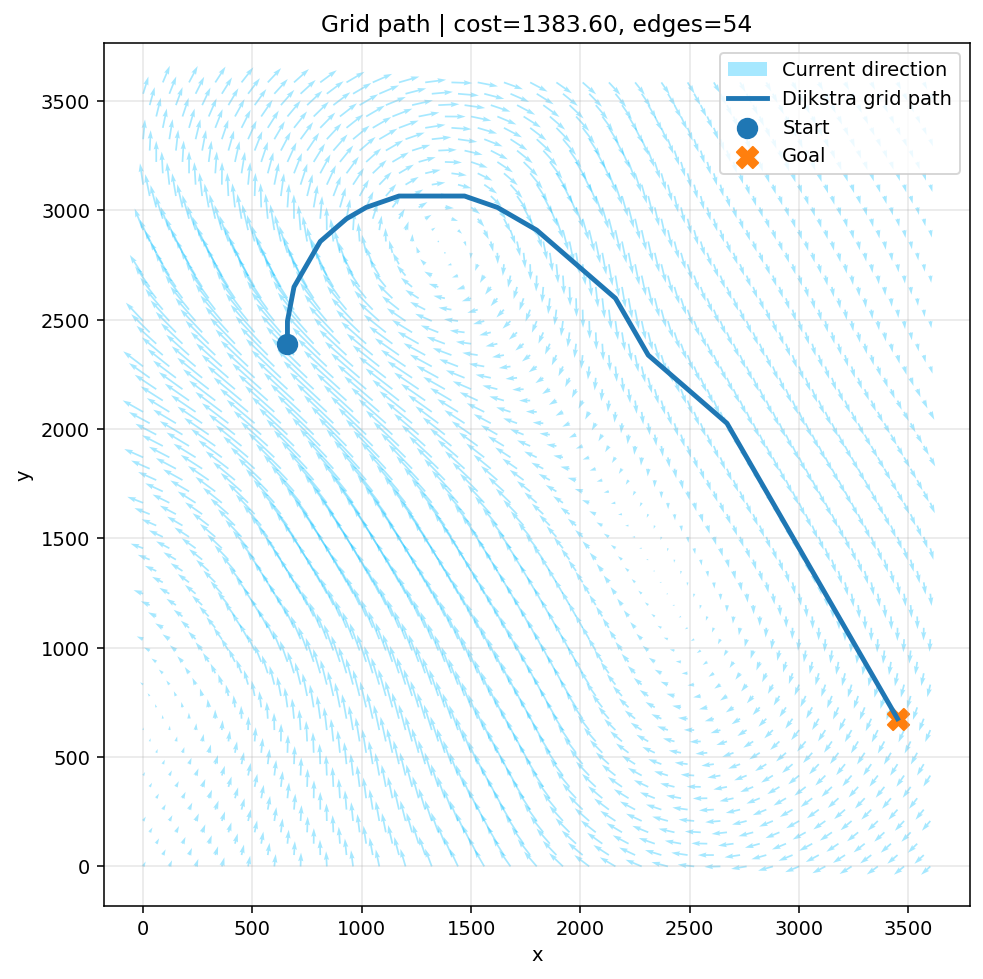

[plot saved] tracking_path.png


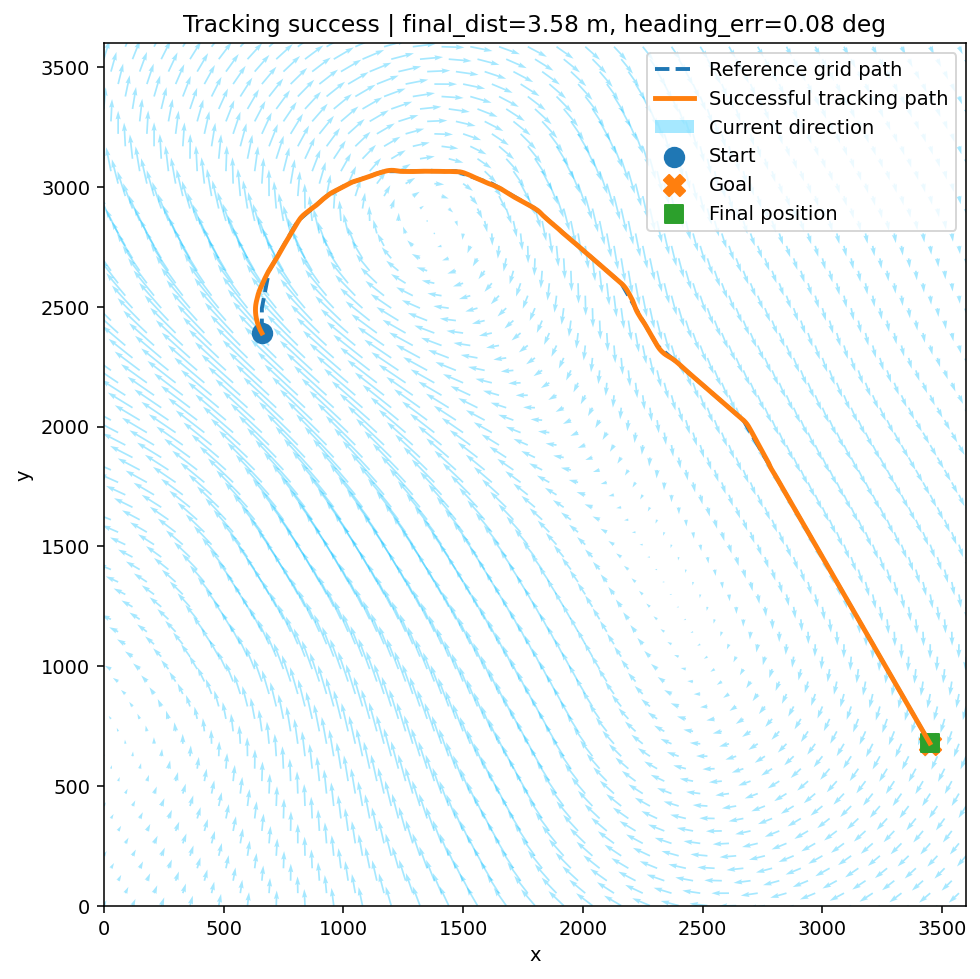

===== One Success Sample =====
route_try              : 0
repeat_id              : 0
start                  : 2794
goal                   : 844
start_heading_deg      : 340.862
goal_heading_deg       : 136.778
path_cost              : 1383.604
path_len_edges         : 54
sim_steps              : 2768
actual_tracking_steps  : 1385
final_dist_m           : 3.579
final_heading_err_deg  : 0.084


In [33]:
one_result = plot_one_success_sample(
    seed=22,
    r=60.0,
    mesh_mod="Hexa",
    neighbor_mode="Extra_extended_edges",
    v_ship=2.5,
    th1=40,
    lam1=0,
    th2=60,
    lam2=np.inf,
    turn_step_deg=2.0,
    goal_tol_pos_m=5.0,
    goal_tol_heading_deg=4.0,
    p_heading=0.5,
    p_closest=0.5,
    p_random=0.0,
    max_route_tries=300,
    max_repeat_sim=100,
    draw_all_edges=False,
)